# 03 · CoT with LLMs — Zero-Shot and Chain-of-Thought prompting

This notebook benchmarks **generative LLM prompting strategies** on the QEvasion
dataset, complementing the encoder fine-tuning approach in `02_train_encoders.ipynb`.

**Model**: `meta-llama/Meta-Llama-3.1-8B-Instruct` (4-bit quantised via bitsandbytes)

Four prompting strategies are compared:
1. **Point 1 — Zero-Shot**: direct classification, no reasoning chain
2. **Point 2 — CoT**: structured Chain-of-Thought with 3 reasoning steps
3. **Point 3 — CoT + Table**: CoT with a full taxonomy table in the system prompt
4. **Point 4 — CoT + Table + RAG**: adds Wikipedia context and question-type heuristics
5. **Point 5 - CoT + Table + Tone**: adds tone of each response

Results are saved to `results/cot/` as JSON, CSV and PNG.

## 0 · Setup (Colab only)

In [ ]:
# ── Google Colab setup ──────────────────────────────────────────────────────
# This cell is a no-op when running locally.
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Install all LLM-specific dependencies
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'numpy>=2.0'], check=True)
    subprocess.run(['pip', 'install', '-q',
        'transformers>=4.44.2', 'accelerate>=0.33.0', 'bitsandbytes>=0.43.3',
        'datasets', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas',
        'tqdm', 'wikipedia-api', 'python-dotenv'], check=True)
    print('Colab dependencies installed.')
else:
    print('Running locally — skipping Colab setup.')

Mounted at /content/drive
Colab dependencies installed.


In [ ]:
# Add project root to sys.path so `src/` is importable from any working directory
import sys
from pathlib import Path

# Move the project to `progettoLLM/` folder in your Drive and update if needed
PROJECT_ROOT = Path('/content/drive/MyDrive/progettoLLM/CLARITY').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)

Project root: /content/drive/.shortcut-targets-by-id/11-EttvNjeVK-tFo3Z6kFaMSmNIJdPVtM/progettoLLM/CLARITY


## 1 · Configuration

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EDIT THIS CELL to change the model or token budgets.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from src.utils.env_utils import is_colab

MODEL_NAME  = 'meta-llama/Meta-Llama-3.1-8B-Instruct'
TEMPERATURE = 0.01   # near-deterministic
SEED        = 42     # must match dataset_loader default for reproducibility

# ── Results directory ──────────────────────────────────────────────────────
# Mirrors the pattern in src/utils/env_utils.py::get_output_dir()
if is_colab():
    SAVE_DIR = Path('/content/drive/MyDrive/progettoLLM/CLARITY/results/cot')
else:
    SAVE_DIR = Path('results/cot')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Official dataset labels ────────────────────────────────────────────────
# Must match the values used in dataset_loader.py / EVASION_TO_CLARITY
CLARITY_LABELS = ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']
EVASION_LABELS = [
    'Explicit', 'Implicit',
    'General', 'Partial/half-answer',
    'Dodging', 'Deflection',
    'Declining to answer', 'Claims ignorance', 'Clarification',
]

# ── Token budgets ──────────────────────────────────────────────────────────
MAX_NEW_TOKENS_ZS   =  50   # zero-shot: label only
MAX_NEW_TOKENS_COT  = 300   # CoT with 3 reasoning steps
MAX_NEW_TOKENS_COT3 = 400   # CoT + taxonomy table
MAX_NEW_TOKENS_COT4 = 450   # CoT + table + RAG

print('Config OK')
print(f'SAVE_DIR         : {SAVE_DIR}')
print(f'Clarity labels   : {CLARITY_LABELS}')
print(f'Evasion labels   : {EVASION_LABELS}')

Config OK
SAVE_DIR         : /content/drive/MyDrive/progettoLLM/CLARITY/results/cot
Clarity labels   : ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']
Evasion labels   : ['Explicit', 'Implicit', 'General', 'Partial/half-answer', 'Dodging', 'Deflection', 'Declining to answer', 'Claims ignorance', 'Clarification']


In [ ]:
import os

if IN_COLAB:
    # Colab Secrets — token is never stored in the notebook file.
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
else:
    # Locally: read from .env file (gitignored — never committed).
    try:
        from dotenv import load_dotenv
        load_dotenv(PROJECT_ROOT / '.env')
    except ImportError:
        pass  # python-dotenv is optional locally
    HF_TOKEN = os.environ.get('HF_TOKEN', '')
    if not HF_TOKEN:
        print('[WARNING] HF_TOKEN not set.')

print(f'HF_TOKEN loaded: {"OK" if HF_TOKEN else "MISSING"}')

HF_TOKEN loaded: OK


## 2 · Load Model

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
)

print(f'Loading {MODEL_NAME} in 4-bit...')
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, token=HF_TOKEN, trust_remote_code=True
)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
    token=HF_TOKEN,
    trust_remote_code=True,
)
model.eval()
print('Model loaded.')
if torch.cuda.is_available():
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Loading meta-llama/Meta-Llama-3.1-8B-Instruct in 4-bit...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded.
  GPU : Tesla T4
  VRAM: 15.6 GB


## 3 · Load Dataset (once — shared by all experiments)

In [ ]:
from src.data.dataset_loader import load_and_split_dataset

print('Loading ailsntua/QEvasion ...')
ds = load_and_split_dataset(seed=SEED, verbose=True)
ds

Loading ailsntua/QEvasion ...


README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

  train       :  3103 samples
  validation  :   345 samples
  test        :   308 samples


DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3103
    })
    validation: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 345
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'anno

In [ ]:
import pandas as pd

# The test split already contains:
#   clarity_label : 3-class label (always populated)
#   evasion_label : 9-class label from majority vote with reliability-weighted
#                   tie-breaking (see src/data/dataset_loader.py)
df_test = ds['test'].to_pandas()

# ── Task 1a/2a/3a/4a : 3-class clarity ────────────────────────────────────
df_test_1a = df_test[
    df_test['clarity_label'].notna() &
    (df_test['clarity_label'].str.strip() != '')
].copy()
df_test_1a['clarity_label'] = df_test_1a['clarity_label'].str.strip()

# ── Task 1b/2b/3b/4b : 9-class evasion ────────────────────────────────────
# evasion_label is already majority-voted; no samples discarded because
# the loader uses reliability-weighted tie-breaking on 3-way ties.
df_test_1b = df_test[df_test['evasion_label'].notna()].copy()
df_test_1b = df_test_1b.rename(columns={'evasion_label': 'evasion_majority'})

print(f'Test set Task 1a (clarity): {len(df_test_1a)} samples')
print(df_test_1a['clarity_label'].value_counts())
print(f'\nTest set Task 1b (evasion): {len(df_test_1b)} samples')
print(df_test_1b['evasion_majority'].value_counts())

Test set Task 1a (clarity): 308 samples
clarity_label
Ambivalent         206
Clear Reply         79
Clear Non-Reply     23
Name: count, dtype: int64

Test set Task 1b (evasion): 308 samples
evasion_majority
Explicit               79
Implicit               67
General                65
Dodging                50
Deflection             20
Declining to answer    11
Claims ignorance        8
Partial/half-answer     4
Clarification           4
Name: count, dtype: int64


## 3.1 · Pre-calculate Tone for Test Set

Uses zero-shot classification to pre-calculate the rhetorical tone of each response.

In [ ]:
from transformers import pipeline
import torch
from tqdm import tqdm
import copy

print('Initializing tone classifier...')
device = "cuda" if torch.cuda.is_available() else "cpu"
tone_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)
candidate_labels = ["Assertive", "Guarded", "Dismissive"]

def apply_tone_to_df(df_original):
    df = df_original.copy()
    tones = []
    for text in tqdm(df['interview_answer'], desc="Calculating Tone"):
        text_str = str(text) if pd.notna(text) else "Unknown"
        text_cut = " ".join(text_str.split()[:200])
        res = tone_classifier(text_cut, candidate_labels=candidate_labels, truncation=True)
        tones.append(res["labels"][0])
    df['tone'] = tones
    # Append the tone to the interview_answer so it gets passed to the LLM automatically
    df['interview_answer'] = df.apply(lambda row: f"[TONE OF RESPONSE: {row['tone']}]\n{row['interview_answer']}", axis=1)
    return df

df_test_1a_tone = apply_tone_to_df(df_test_1a)
df_test_1b_tone = apply_tone_to_df(df_test_1b)
print('Tone analysis complete. Test sets mapped.')


Initializing tone classifier...


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Calculating Tone: 100%|██████████| 308/308 [00:27<00:00, 11.16it/s]

Tone analysis complete. Test sets mapped.


## 4 · Inference Utilities

In [ ]:
import re
import warnings
import pandas as pd
from tqdm import tqdm
warnings.filterwarnings('ignore')


def predict(system_prompt: str, question: str, answer: str,
            max_new_tokens: int = MAX_NEW_TOKENS_ZS) -> str:
    """
    Zero-shot prediction: returns the raw model output string.

    Args:
        system_prompt  : System-role instruction.
        question       : Journalist question.
        answer         : Politician answer.
        max_new_tokens : Maximum tokens to generate.
    Returns:
        Raw decoded string from the model.
    """
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': f'QUESTION: {question}\n\nANSWER: {answer}'},
    ]
    prompt_str = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    inputs = tokenizer(
        prompt_str, return_tensors='pt', add_special_tokens=False
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            temperature=TEMPERATURE,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated_ids = out[0][inputs['input_ids'].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def parse_label(raw: str, valid_labels: list) -> str:
    """
    Map raw model output to the closest valid label.
    Tries exact match, then known shortcuts, then partial match.
    Returns 'PARSE_ERROR' if no match is found.
    """
    raw_l = raw.lower().strip()
    for lbl in valid_labels:
        if lbl.lower() == raw_l:
            return lbl
    shortcuts = {
        'non-reply':       'Clear Non-Reply',
        'non reply':       'Clear Non-Reply',
        'clear non reply': 'Clear Non-Reply',
        'clear reply':     'Clear Reply',
        'decline':         'Declining to answer',
        'declining':       'Declining to answer',
        'ignorance':       'Claims ignorance',
        'claims':          'Claims ignorance',
        'partial':         'Partial/half-answer',
        'half-answer':     'Partial/half-answer',
    }
    for key, val in shortcuts.items():
        if key in raw_l and val in valid_labels:
            return val
    for lbl in valid_labels:
        if lbl.lower() in raw_l or raw_l in lbl.lower():
            return lbl
    return 'PARSE_ERROR'


def run_inference(df: pd.DataFrame,
                  system_prompt: str,
                  label_col: str,
                  valid_labels: list,
                  exp_name: str,
                  csv_path: str) -> pd.DataFrame:
    import os
    if os.path.exists(csv_path):
        df_saved = pd.read_csv(csv_path)
        processed = set(df_saved['question'].astype(str))
        print(f'[{exp_name}] Checkpoint found: skipping {len(processed)} rows.')
        mode, header = 'a', False
    else:
        processed = set()
        print(f'[{exp_name}] No checkpoint: starting from scratch.')
        mode, header = 'w', True

    try:
        for _, row in tqdm(df.iterrows(), total=len(df), desc=exp_name):
            q = str(row['question'])
            if q in processed:
                continue
            a = str(row['interview_answer'])
            true = str(row[label_col])
            try:
                raw = predict(system_prompt, q, a)
                pred = parse_label(raw, valid_labels)
            except Exception as e:
                raw = f'ERROR: {e}'
                pred = 'PARSE_ERROR'
            record = {
                'question':       q,
                'answer_snippet': a[:150],
                'true_label':     true,
                'pred_label':     pred,
                'raw_output':     raw,
            }
            pd.DataFrame([record]).to_csv(csv_path, mode=mode, header=header, index=False)
            mode, header = 'a', False
    except KeyboardInterrupt:
        print('[!] Interrupted. Progress saved to CSV.')

    return pd.read_csv(csv_path)


print('Zero-shot inference functions defined.')

Zero-shot inference functions defined.


In [ ]:
def _fuzzy_match(text: str, valid_labels: list) -> str:
    """Exact then partial label match; returns 'PARSE_ERROR' on failure."""
    text_l = text.lower().strip()
    for lbl in valid_labels:
        if lbl.lower() == text_l:
            return lbl
    shortcuts = {
        'non-reply':       'Clear Non-Reply',
        'non reply':       'Clear Non-Reply',
        'clear non reply': 'Clear Non-Reply',
        'clear reply':     'Clear Reply',
        'decline':         'Declining to answer',
        'declining':       'Declining to answer',
        'ignorance':       'Claims ignorance',
        'claims':          'Claims ignorance',
        'partial':         'Partial/half-answer',
        'half-answer':     'Partial/half-answer',
    }
    for key, val in shortcuts.items():
        if key in text_l and val in valid_labels:
            return val
    for lbl in valid_labels:
        if lbl.lower() in text_l:
            return lbl
    return 'PARSE_ERROR'


def parse_cot_label(raw: str, valid_labels: list) -> str:
    """
    Extract the prediction from a CoT output.
    Priority: <label>...</label> tag -> last line -> full-text scan.
    """
    match = re.search(r'<label>\s*(.*?)\s*</label>', raw, re.IGNORECASE | re.DOTALL)
    if match:
        parsed = _fuzzy_match(match.group(1).strip(), valid_labels)
        if parsed != 'PARSE_ERROR':
            return parsed
    last_line = raw.strip().split('\n')[-1].strip()
    parsed = _fuzzy_match(last_line, valid_labels)
    if parsed != 'PARSE_ERROR':
        return parsed
    for lbl in valid_labels:
        if lbl.lower() in raw.lower():
            return lbl
    return 'PARSE_ERROR'


def predict_cot(system_prompt: str, question: str, answer: str,
                max_new_tokens: int = MAX_NEW_TOKENS_COT) -> tuple:
    """
    CoT prediction: returns (raw_output, reasoning_text).
    reasoning_text concatenates all <stepN>...</stepN> blocks.
    """
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': f'QUESTION: {question}\n\nANSWER: {answer}'},
    ]
    prompt_str = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    inputs = tokenizer(
        prompt_str, return_tensors='pt', add_special_tokens=False
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            temperature=TEMPERATURE,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated_ids = out[0][inputs['input_ids'].shape[-1]:]
    raw = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    steps = re.findall(r'<step\d>(.*?)</step\d>', raw, re.DOTALL)
    reasoning = ' | '.join(s.strip() for s in steps) if steps else ''
    return raw, reasoning


def run_inference_cot_with_checkpoint(df: pd.DataFrame,
                                       system_prompt: str,
                                       label_col: str,
                                       valid_labels: list,
                                       exp_name: str,
                                       csv_path: str,
                                       max_new_tokens: int = 300) -> pd.DataFrame:
    """
    CoT inference with row-level checkpointing.

    Each row is written to disk immediately after generation.
    If interrupted, re-running resumes from where it stopped.

    Args:
        df            : Test DataFrame.
        system_prompt : System-role instruction.
        label_col     : Column name for ground-truth labels.
        valid_labels  : List of valid output labels.
        exp_name      : Experiment name (used in progress bar).
        csv_path      : Full path to the checkpoint CSV file.
    Returns:
        DataFrame loaded from csv_path (may be partial if interrupted).
    """
    import os
    if os.path.exists(csv_path):
        df_saved = pd.read_csv(csv_path)
        processed_questions = set(df_saved['question'].astype(str))
        print(f'[{exp_name}] Checkpoint found: skipping {len(processed_questions)} rows.')
        mode, header = 'a', False
    else:
        processed_questions = set()
        print(f'[{exp_name}] No checkpoint: starting from scratch.')
        mode, header = 'w', True
    try:
        for _, row in tqdm(df.iterrows(), total=len(df), desc=exp_name):
            q = str(row['question'])
            if q in processed_questions:
                continue
            a    = str(row['interview_answer'])
            true = str(row[label_col])
            try:
                raw, reasoning = predict_cot(system_prompt, q, a, max_new_tokens=max_new_tokens)
                pred = parse_cot_label(raw, valid_labels)
            except Exception as e:
                raw, reasoning, pred = f'ERROR: {e}', '', 'PARSE_ERROR'
            record = {
                'question':       q,
                'answer_snippet': a[:150],
                'true_label':     true,
                'pred_label':     pred,
                'reasoning':      reasoning,
                'raw_output':     raw,
            }
            pd.DataFrame([record]).to_csv(csv_path, mode=mode, header=header, index=False)
            mode, header = 'a', False
    except KeyboardInterrupt:
        print('\n[!] Interrupted. Progress saved to CSV.')
    return pd.read_csv(csv_path)


print('CoT inference functions defined.')

CoT inference functions defined.


## 5 · Evaluation Utilities

In [ ]:
import json as _json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix,
)


def evaluate_and_plot(df_results: pd.DataFrame,
                      valid_labels: list,
                      exp_name: str,
                      save_dir) -> dict:
    """
    Compute metrics and save three plots + a JSON metrics file.

    Plots:
      1. Confusion matrix (raw counts + row-normalised)
      2. Per-class F1 bar chart
      3. Label distribution: true vs predicted

    Args:
        df_results   : DataFrame with columns true_label and pred_label.
        valid_labels : Ordered list of class names.
        exp_name     : Experiment identifier used in file names.
        save_dir     : Destination directory (str or Path).
    Returns:
        Metrics dict with keys: experiment, n_total, n_parse_errors,
        n_valid, accuracy, macro_f1, weighted_f1, per_class_f1.
    """
    save_dir = str(save_dir)
    valid    = df_results[df_results['pred_label'] != 'PARSE_ERROR'].copy()
    n_err    = (df_results['pred_label'] == 'PARSE_ERROR').sum()
    n_tot    = len(df_results)
    n_val    = len(valid)
    y_true   = valid['true_label'].tolist()
    y_pred   = valid['pred_label'].tolist()

    acc         = accuracy_score(y_true, y_pred)
    macro_f1    = f1_score(y_true, y_pred, average='macro',    labels=valid_labels, zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', labels=valid_labels, zero_division=0)
    per_class   = f1_score(y_true, y_pred, average=None,       labels=valid_labels, zero_division=0)

    print('\n' + '='*60)
    print(f'  {exp_name}')
    print('='*60)
    print(f'  Total samples  : {n_tot}')
    print(f'  Parse errors   : {n_err}  ({n_err/n_tot*100:.1f}%)')
    print(f'  Valid samples  : {n_val}')
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  Macro F1       : {macro_f1:.4f}')
    print(f'  Weighted F1    : {weighted_f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, labels=valid_labels, zero_division=0))

    n_cols = len(valid_labels)

    # ── Plot 1: Confusion Matrix ───────────────────────────────────────────
    cm      = confusion_matrix(y_true, y_pred, labels=valid_labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig_w   = max(14, n_cols * 1.8)
    fig, axes = plt.subplots(1, 2, figsize=(fig_w, 5))
    fig.suptitle(f'{exp_name}\nMacro F1={macro_f1:.3f} | Accuracy={acc:.3f}',
                 fontsize=13, fontweight='bold')
    for ax, mat, title in zip(axes, [cm, cm_norm], ['Counts', 'Normalized (row)']):
        im = ax.imshow(mat, interpolation='nearest', cmap='Blues')
        ax.set_title(title, fontsize=11)
        ax.set_xticks(range(n_cols)); ax.set_yticks(range(n_cols))
        ax.set_xticklabels(valid_labels, rotation=35, ha='right', fontsize=8)
        ax.set_yticklabels(valid_labels, fontsize=8)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        thresh = mat.max() / 2
        for i in range(n_cols):
            for j in range(n_cols):
                val = f'{mat[i,j]:.2f}' if title != 'Counts' else str(int(mat[i,j]))
                ax.text(j, i, val, ha='center', va='center',
                        color='white' if mat[i,j] > thresh else 'black', fontsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    p = f'{save_dir}/{exp_name}_confusion_matrix.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Saved -> {p}')

    # ── Plot 2: Per-class F1 ───────────────────────────────────────────────
    colors = plt.cm.RdYlGn(np.linspace(0.15, 0.9, n_cols))
    fig, ax = plt.subplots(figsize=(max(9, n_cols*1.2), 4.5))
    bars = ax.bar(valid_labels, per_class, color=colors, edgecolor='black', linewidth=0.6)
    ax.axhline(macro_f1, color='navy', linestyle='--', linewidth=1.5,
               label=f'Macro F1 = {macro_f1:.3f}')
    ax.set_ylim(0, 1.1); ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title(f'{exp_name} — Per-class F1', fontsize=12, fontweight='bold')
    ax.set_xticklabels(valid_labels, rotation=30, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    for bar, val in zip(bars, per_class):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    p = f'{save_dir}/{exp_name}_f1_per_class.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Saved -> {p}')

    # ── Plot 3: Label distribution ─────────────────────────────────────────
    tc = Counter(y_true); pc = Counter(y_pred)
    x = np.arange(n_cols); w = 0.35
    fig, ax = plt.subplots(figsize=(max(9, n_cols*1.2), 4.5))
    ax.bar(x - w/2, [tc.get(l, 0) for l in valid_labels], w,
           label='True',      color='steelblue', alpha=0.85, edgecolor='black')
    ax.bar(x + w/2, [pc.get(l, 0) for l in valid_labels], w,
           label='Predicted', color='salmon',    alpha=0.85, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(valid_labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{exp_name} — Label Distribution: True vs Predicted',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    p = f'{save_dir}/{exp_name}_label_distribution.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Saved -> {p}')

    # ── Save metrics JSON ──────────────────────────────────────────────────
    metrics = {
        'experiment':     exp_name,
        'n_total':        int(n_tot),
        'n_parse_errors': int(n_err),
        'n_valid':        int(n_val),
        'accuracy':       round(acc, 4),
        'macro_f1':       round(macro_f1, 4),
        'weighted_f1':    round(weighted_f1, 4),
        'per_class_f1':   {l: round(float(f), 4) for l, f in zip(valid_labels, per_class)},
    }
    p = f'{save_dir}/{exp_name}_metrics.json'
    with open(p, 'w') as fp:
        _json.dump(metrics, fp, indent=2)
    print(f'  Saved -> {p}')
    return metrics


print('Evaluation utilities defined.')

Evaluation utilities defined.


## 6 · Point 1 — Zero-Shot

Direct classification without any reasoning chain. The model receives only the
question, the answer, and a brief definition of each label. Serves as the baseline.

In [ ]:
SYSTEM_1A = """\
You are an expert in political discourse analysis.
Your task is to classify the CLARITY of a politician's answer to a journalist's question.

Choose exactly ONE label from:
  - Clear Reply      : The answer directly provides the requested information.
  - Ambivalent       : The answer partially addresses the question or is vague.
  - Clear Non-Reply  : The answer explicitly avoids or refuses to answer.

Respond with ONLY the label. No explanation."""

SYSTEM_1B = """\
You are an expert in political discourse analysis.
Your task is to classify the EVASION TECHNIQUE used in a politician's answer.

Choose exactly ONE label from:
  - Explicit            : directly and fully answers in the expected form
  - Implicit            : answers indirectly; info can be inferred
  - General             : answer is too vague, lacks requested specificity
  - Partial/half-answer : answers only part of the question
  - Dodging             : ignores the question entirely, topic switch
  - Deflection          : starts on-topic then shifts to a different point
  - Declining to answer : explicitly refuses to answer
  - Claims ignorance    : admits not knowing the answer
  - Clarification       : asks what the question means instead of answering

Respond with ONLY the label. No explanation."""

print('Zero-shot system prompts defined.')

Zero-shot system prompts defined.


POINT 1a — Zero-Shot, 3-class clarity
Samples: 308
[1a_zeroshot_clarity] Checkpoint found: skipping 308 rows.


1a_zeroshot_clarity: 100%|██████████| 308/308 [00:00<00:00, 4928.58it/s]

Predictions saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1a_zeroshot_clarity_predictions.csv

  1a_zeroshot_clarity
  Total samples  : 308
  Parse errors   : 0  (0.0%)
  Valid samples  : 308
  Accuracy       : 0.2500
  Macro F1       : 0.2580
  Weighted F1    : 0.2993



                 precision    recall  f1-score   support

    Clear Reply       0.42      0.30      0.35        79
     Ambivalent       0.65      0.19      0.30       206
Clear Non-Reply       0.07      0.57      0.12        23

       accuracy                           0.25       308
      macro avg       0.38      0.35      0.26       308
   weighted avg       0.54      0.25      0.30       308



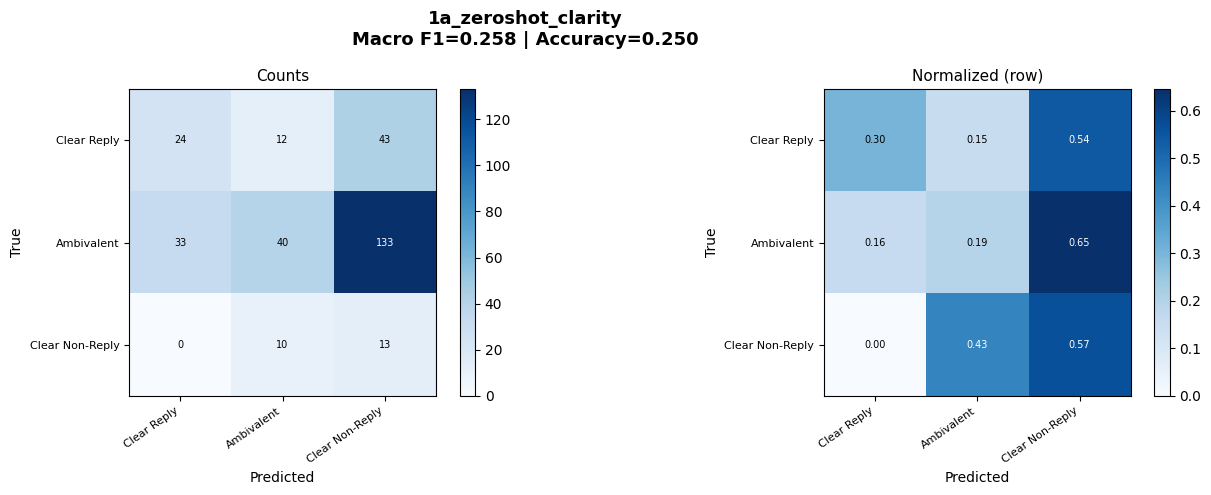

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1a_zeroshot_clarity_confusion_matrix.png


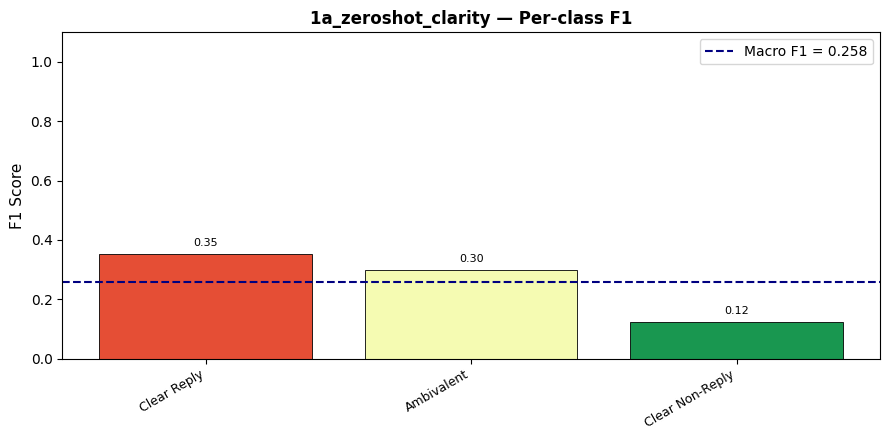

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1a_zeroshot_clarity_f1_per_class.png


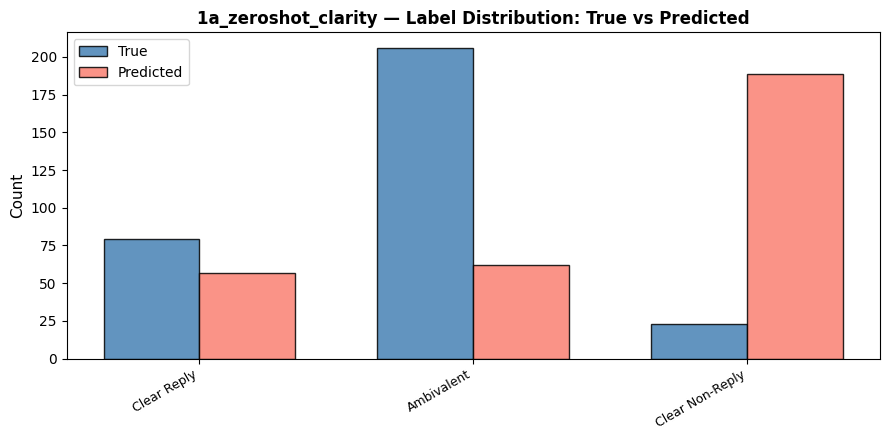

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1a_zeroshot_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1a_zeroshot_clarity_metrics.json


In [ ]:
print('POINT 1a — Zero-Shot, 3-class clarity')
print(f'Samples: {len(df_test_1a)}')

df_res_1a = run_inference(
    df           = df_test_1a,
    system_prompt= SYSTEM_1A,
    label_col    = 'clarity_label',
    valid_labels = CLARITY_LABELS,
    exp_name     = '1a_zeroshot_clarity',
    csv_path     = str(SAVE_DIR / '1a_zeroshot_clarity_predictions.csv'),
)

csv_path = str(SAVE_DIR / '1a_zeroshot_clarity_predictions.csv')
df_res_1a.to_csv(csv_path, index=False)
print(f'Predictions saved -> {csv_path}')

metrics_1a = evaluate_and_plot(
    df_results   = df_res_1a,
    valid_labels = CLARITY_LABELS,
    exp_name     = '1a_zeroshot_clarity',
    save_dir     = SAVE_DIR,
)

POINT 1b — Zero-Shot, 9-class evasion (majority-voted ground truth)
Samples: 308
[1b_zeroshot_evasion] Checkpoint found: skipping 308 rows.


1b_zeroshot_evasion: 100%|██████████| 308/308 [00:00<00:00, 20100.60it/s]

Predictions saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1b_zeroshot_evasion_predictions.csv

  1b_zeroshot_evasion
  Total samples  : 308
  Parse errors   : 0  (0.0%)
  Valid samples  : 308
  Accuracy       : 0.1266
  Macro F1       : 0.1178
  Weighted F1    : 0.0971

                     precision    recall  f1-score   support

           Explicit       1.00      0.04      0.07        79
           Implicit       1.00      0.01      0.03        67
            General       0.00      0.00      0.00        65
Partial/half-answer       0.00      0.00      0.00         4
            Dodging       0.36      0.24      0.29        50
         Deflection       0.07      0.90      0.13        20
Declining to answer       0.40      0.18      0.25        11
   Claims ignorance       0.23      0.38      0.29         8
      Clarification       0.00      0.00      0.00         4

           accuracy                           0.13       308
          macro avg       0.34      0.

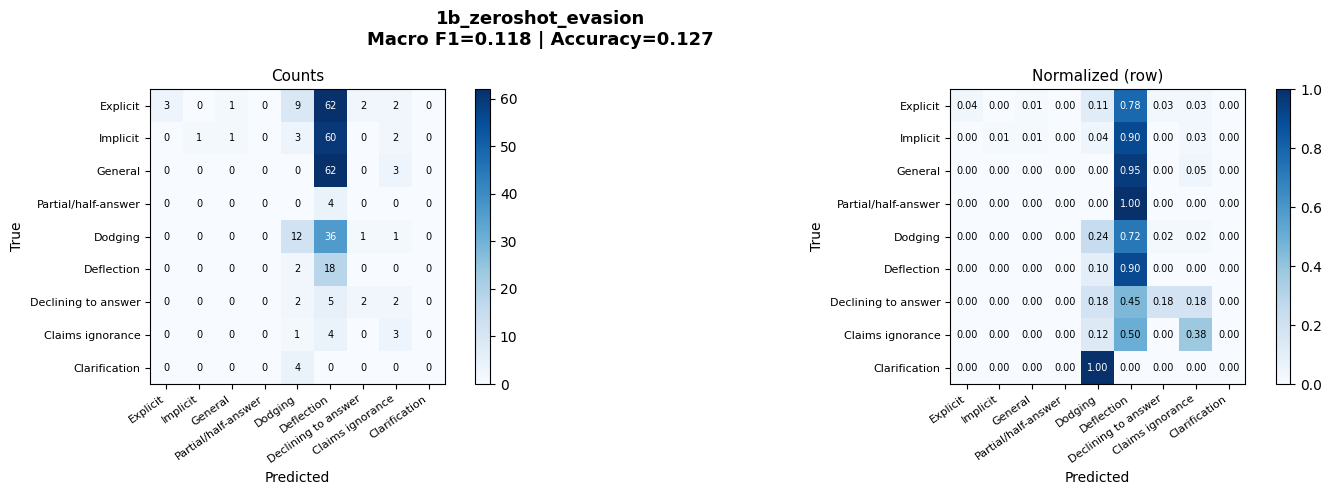

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1b_zeroshot_evasion_confusion_matrix.png


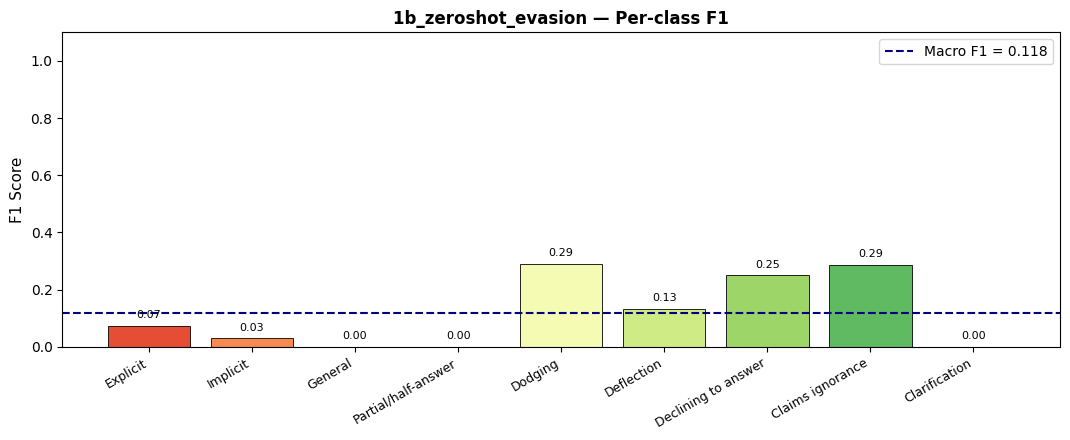

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1b_zeroshot_evasion_f1_per_class.png


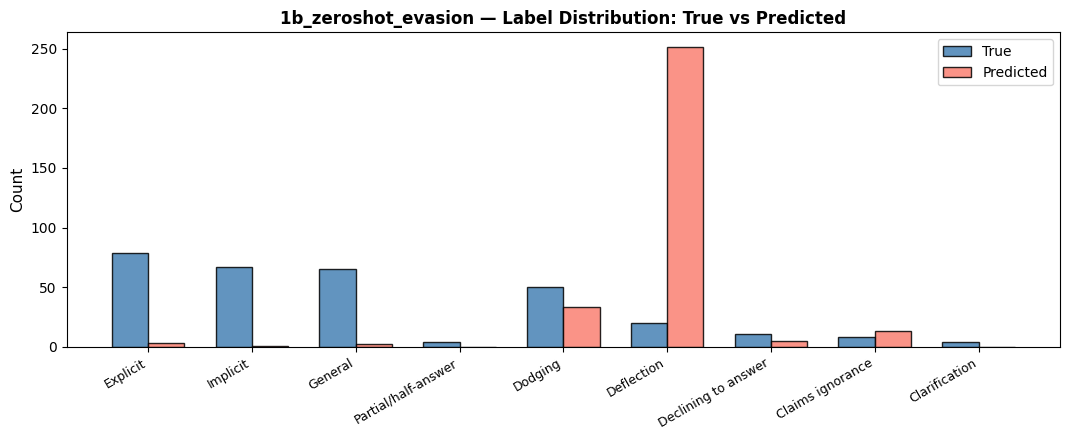

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1b_zeroshot_evasion_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1b_zeroshot_evasion_metrics.json


In [ ]:
print('POINT 1b — Zero-Shot, 9-class evasion (majority-voted ground truth)')
print(f'Samples: {len(df_test_1b)}')

df_res_1b = run_inference(
    df           = df_test_1b,
    system_prompt= SYSTEM_1B,
    label_col    = 'evasion_majority',
    valid_labels = EVASION_LABELS,
    exp_name     = '1b_zeroshot_evasion',
    csv_path     = str(SAVE_DIR / '1b_zeroshot_evasion_predictions.csv'),
)

csv_path = str(SAVE_DIR / '1b_zeroshot_evasion_predictions.csv')
df_res_1b.to_csv(csv_path, index=False)
print(f'Predictions saved -> {csv_path}')

metrics_1b = evaluate_and_plot(
    df_results   = df_res_1b,
    valid_labels = EVASION_LABELS,
    exp_name     = '1b_zeroshot_evasion',
    save_dir     = SAVE_DIR,
)

## 7 · Point 2 — Chain-of-Thought (CoT)

The model is asked to reason through three structured steps before outputting
the final label inside `<label>...</label>` tags.
Inference uses row-level checkpointing: safe to interrupt and resume.

In [ ]:
SYSTEM_2A = """\
You are an expert in political discourse analysis.
Your task is to classify the CLARITY of a politician's answer to a journalist's question.

The three possible labels are:
  - Clear Reply     : The answer directly provides the requested information.
  - Ambivalent      : The answer partially addresses the question or is too vague.
  - Clear Non-Reply : The answer explicitly avoids or refuses to answer.

Think step by step before classifying:

<step1>
What specific information is the journalist requesting?
Summarize the core of the question in one sentence.
</step1>

<step2>
How does the politician respond? Describe what the answer actually does:
- Does it directly provide the requested information?
- Does it acknowledge the question but avoid it?
- Does it ignore the question entirely?
- Does it shift to a related but different topic?
- Does it provide only part of the answer?
- Does it ask for clarification instead?
</step2>

<step3>
Based on your analysis, which label fits best?
Consider:
- Clear Reply    = directly and completely answers what was asked
- Ambivalent     = partially relevant or too vague
- Clear Non-Reply= explicitly refuses or declines
</step3>

Output the final label inside <label> tags.
Choose exactly ONE of: Clear Reply | Ambivalent | Clear Non-Reply

Output format:
<step1>...</step1>
<step2>...</step2>
<step3>...</step3>
<label>YOUR LABEL HERE</label>"""


SYSTEM_2B = """\
You are an expert in political discourse analysis.
Your task is to classify the EVASION TECHNIQUE used in a politician's answer to a journalist's question.

The nine possible labels are:
  - Explicit            : directly and fully answers in the expected form
  - Implicit            : answers indirectly; info can be inferred
  - General             : answer is too vague, lacks requested specificity
  - Partial/half-answer : answers only part of the question
  - Dodging             : ignores the question entirely, topic switch
  - Deflection          : starts on-topic then shifts to a different point
  - Declining to answer : explicitly refuses to answer
  - Claims ignorance    : admits not knowing the answer
  - Clarification       : asks what the question means instead of answering

Think step by step before classifying:

<step1>
What specific information is the journalist requesting?
Summarize the core of the question in one sentence.
</step1>

<step2>
How does the politician respond? Describe what the answer actually does:
- Does it directly provide the requested information?
- Does it acknowledge the question but avoid it?
- Does it ignore the question entirely?
- Does it shift to a related but different topic?
- Does it provide only part of the answer?
- Does it ask for clarification instead?
</step2>

<step3>
Based on your analysis, which technique best matches?
Consider these key distinctions:
- Dodging vs Deflection: Dodging = zero engagement, jumps to unrelated topic.
  Deflection = partial engagement, then pivots to different point.
- General vs Partial/half-answer: General = answers but too vaguely.
  Partial/half-answer = answers specifically but only covers part of what was asked.
- Explicit vs Implicit: Explicit = directly states the requested info.
  Implicit = info must be inferred; never stated directly.
- Declining vs Dodging: Declining = acknowledges the question then refuses.
  Dodging = does not acknowledge the question at all.
</step3>

Output the final label inside <label> tags.
Choose exactly ONE of: Explicit | Implicit | General | Partial/half-answer | Dodging | Deflection | Declining to answer | Claims ignorance | Clarification

Output format:
<step1>...</step1>
<step2>...</step2>
<step3>...</step3>
<label>YOUR LABEL HERE</label>"""

print(f'CoT system prompts defined. MAX_NEW_TOKENS_COT = {MAX_NEW_TOKENS_COT}')

CoT system prompts defined. MAX_NEW_TOKENS_COT = 300


POINT 2a — CoT, 3-class clarity
Samples: 308  |  max_new_tokens: 300
[2a_cot_clarity] Checkpoint found: skipping 308 rows.


2a_cot_clarity: 100%|██████████| 308/308 [00:00<00:00, 20145.11it/s]

Predictions loaded/saved from -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2a_cot_clarity_predictions.csv

  2a_cot_clarity
  Total samples  : 308
  Parse errors   : 0  (0.0%)
  Valid samples  : 308
  Accuracy       : 0.2273
  Macro F1       : 0.1897
  Weighted F1    : 0.2432

                 precision    recall  f1-score   support

    Clear Reply       1.00      0.04      0.07        79
     Ambivalent       0.60      0.21      0.32       206
Clear Non-Reply       0.10      1.00      0.18        23

       accuracy                           0.23       308
      macro avg       0.57      0.42      0.19       308
   weighted avg       0.67      0.23      0.24       308



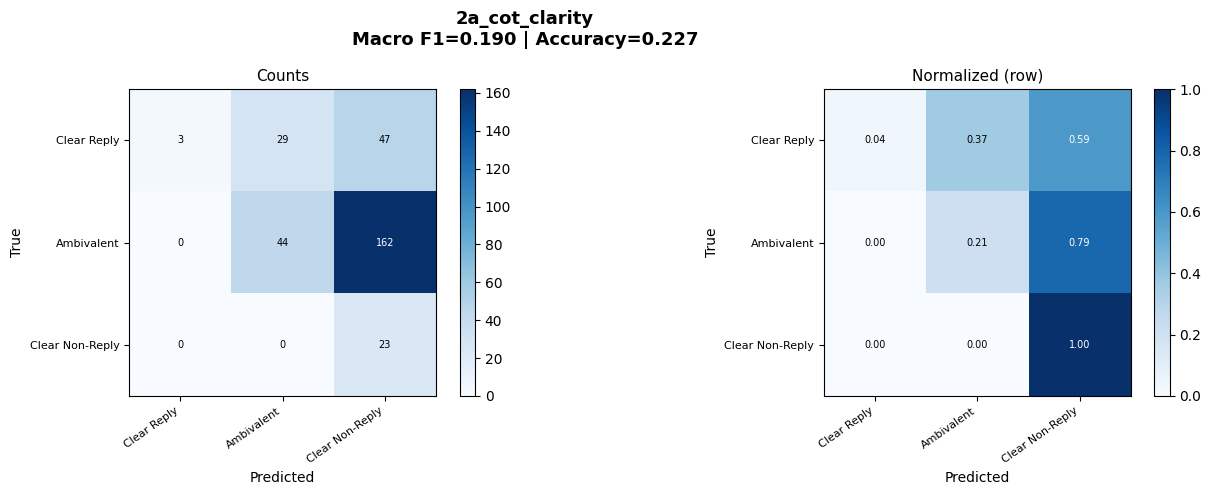

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2a_cot_clarity_confusion_matrix.png


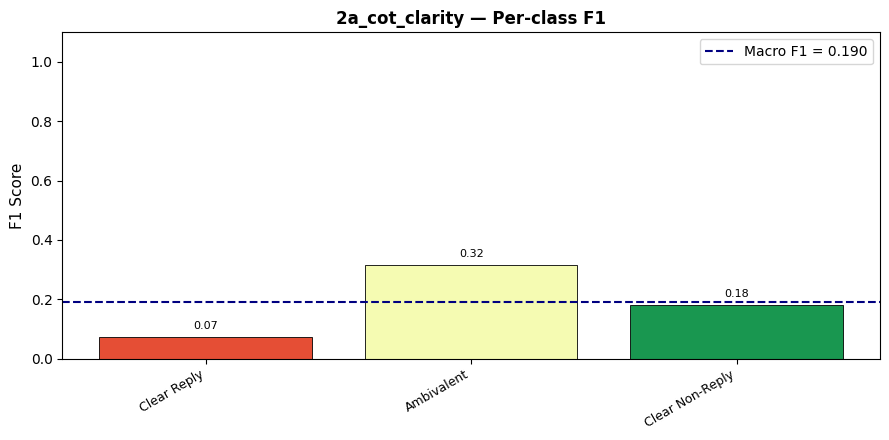

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2a_cot_clarity_f1_per_class.png


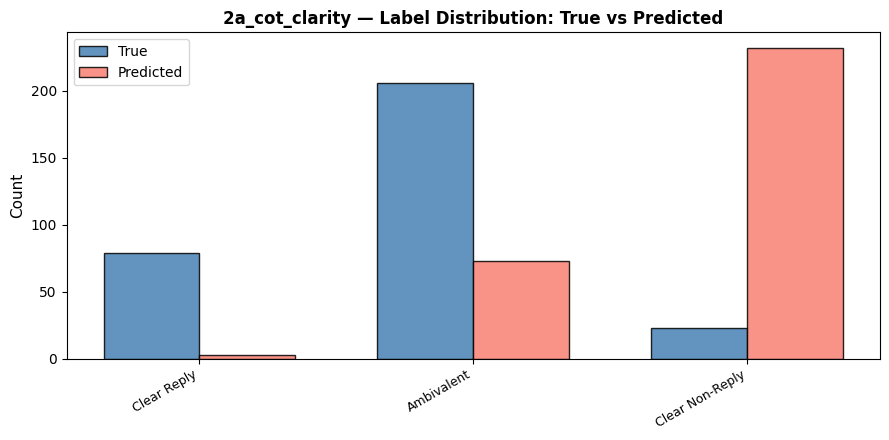

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2a_cot_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2a_cot_clarity_metrics.json


In [ ]:
print('POINT 2a — CoT, 3-class clarity')
print(f'Samples: {len(df_test_1a)}  |  max_new_tokens: {MAX_NEW_TOKENS_COT}')

csv_path_2a = str(SAVE_DIR / '2a_cot_clarity_predictions.csv')

df_res_2a = run_inference_cot_with_checkpoint(
    df            = df_test_1a,
    system_prompt = SYSTEM_2A,
    label_col     = 'clarity_label',
    valid_labels  = CLARITY_LABELS,
    exp_name      = '2a_cot_clarity',
    csv_path      = csv_path_2a,
    max_new_tokens= MAX_NEW_TOKENS_COT,
)

print(f'Predictions loaded/saved from -> {csv_path_2a}')

if len(df_res_2a) == len(df_test_1a):
    metrics_2a = evaluate_and_plot(
        df_results   = df_res_2a,
        valid_labels = CLARITY_LABELS,
        exp_name     = '2a_cot_clarity',
        save_dir     = SAVE_DIR,
    )
else:
    print(f'[!] Inference incomplete ({len(df_res_2a)}/{len(df_test_1a)}). Re-run to continue.')

POINT 2b — CoT, 9-class evasion (majority-voted ground truth)
Samples: 308  |  max_new_tokens: 300
[2b_cot_evasion] Checkpoint found: skipping 308 rows.


2b_cot_evasion: 100%|██████████| 308/308 [00:00<00:00, 12678.83it/s]

Predictions loaded/saved from -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2b_cot_evasion_predictions.csv

  2b_cot_evasion
  Total samples  : 308
  Parse errors   : 1  (0.3%)
  Valid samples  : 307
  Accuracy       : 0.1498
  Macro F1       : 0.1694
  Weighted F1    : 0.1234

                     precision    recall  f1-score   support

           Explicit       1.00      0.03      0.05        79
           Implicit       0.00      0.00      0.00        67
            General       0.18      0.12      0.15        64
Partial/half-answer       0.00      0.00      0.00         4
            Dodging       0.28      0.36      0.31        50
         Deflection       0.07      0.65      0.13        20
Declining to answer       0.30      0.27      0.29        11
   Claims ignorance       0.50      0.12      0.20         8
      Clarification       1.00      0.25      0.40         4

           accuracy                           0.15       307
          macro avg       0.37      

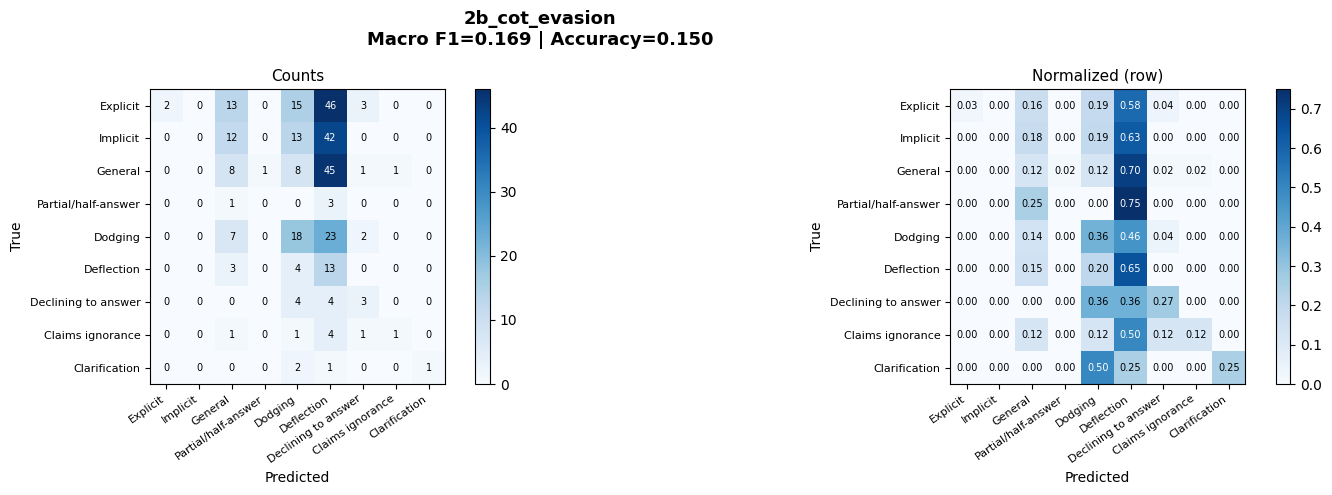

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2b_cot_evasion_confusion_matrix.png


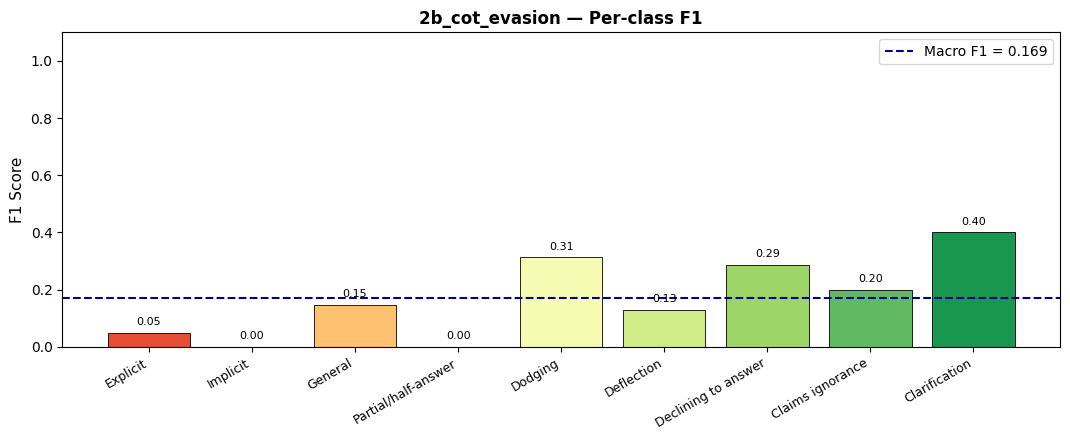

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2b_cot_evasion_f1_per_class.png


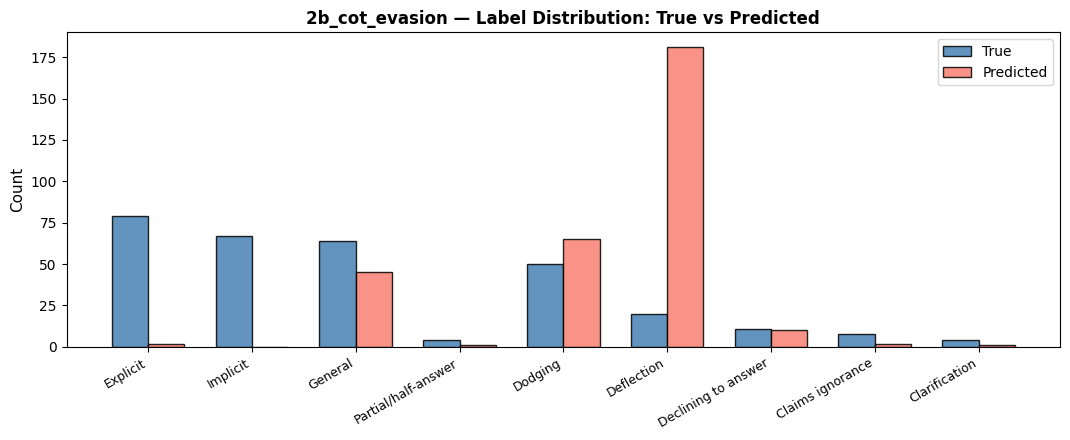

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2b_cot_evasion_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2b_cot_evasion_metrics.json


In [ ]:
print('POINT 2b — CoT, 9-class evasion (majority-voted ground truth)')
print(f'Samples: {len(df_test_1b)}  |  max_new_tokens: {MAX_NEW_TOKENS_COT}')

csv_path_2b = str(SAVE_DIR / '2b_cot_evasion_predictions.csv')

df_res_2b = run_inference_cot_with_checkpoint(
    df            = df_test_1b,
    system_prompt = SYSTEM_2B,
    label_col     = 'evasion_majority',
    valid_labels  = EVASION_LABELS,
    exp_name      = '2b_cot_evasion',
    csv_path      = csv_path_2b,
    max_new_tokens= MAX_NEW_TOKENS_COT,
)

print(f'Predictions loaded/saved from -> {csv_path_2b}')

if len(df_res_2b) == len(df_test_1b):
    metrics_2b = evaluate_and_plot(
        df_results   = df_res_2b,
        valid_labels = EVASION_LABELS,
        exp_name     = '2b_cot_evasion',
        save_dir     = SAVE_DIR,
    )
else:
    print(f'[!] Inference incomplete ({len(df_res_2b)}/{len(df_test_1b)}). Re-run to continue.')

## 8 · Point 3 — CoT + Taxonomy Table

Same CoT structure as Point 2, but the system prompt now includes a full
ASCII taxonomy table with definitions and examples taken directly from the
annotation guidelines used by human annotators.

In [ ]:
SYSTEM_3A = """\
You are an expert in political discourse analysis.
Your task is to classify the CLARITY of a politician's answer to a journalist's question.

Use the following taxonomy (used by human expert annotators):

+------------------+---------------------------------------------------------------+
| LABEL            | DEFINITION + EXAMPLE                                         |
+------------------+---------------------------------------------------------------+
| Clear Reply      | The answer directly provides the requested information,       |
|                  | explicitly or implicitly.                                     |
|                  | Q: "Do you support this bill?"  A: "Yes, I do."              |
+------------------+---------------------------------------------------------------+
| Ambivalent       | The answer partially addresses the question, is too vague,    |
|                  | or only covers part of what was asked.                        |
|                  | Q: "What is your plan?"  A: "We will look into it."          |
+------------------+---------------------------------------------------------------+
| Clear Non-Reply  | The answer explicitly avoids or refuses to address the        |
|                  | question (declining, claiming ignorance, or asking for        |
|                  | clarification).                                               |
|                  | Q: "Will you resign?"  A: "I am not going to comment."       |
+------------------+---------------------------------------------------------------+

Think step by step:

<step1>
What specific information is the journalist requesting?
Identify the core question in one sentence.
</step1>

<step2>
What does the answer actually do?
- Does it engage with the question topic at all?
- Does it provide the specific information requested?
- Does it acknowledge the question before avoiding it?
Describe concretely what the answer does, then match it to the taxonomy above.
</step2>

<step3>
Apply the taxonomy. Which label fits best?
Why is it better than the other two options?
</step3>

Output the final label inside <label> tags.
Choose exactly ONE of: Clear Reply | Ambivalent | Clear Non-Reply

Output format:
<step1>...</step1>
<step2>...</step2>
<step3>...</step3>
<label>YOUR LABEL HERE</label>"""


SYSTEM_3B = """\
You are an expert in political discourse analysis.
Your task is to classify the EVASION TECHNIQUE used in a politician's answer to a journalist's question.

Use the following taxonomy (the exact guide used by human expert annotators):

+----------------------+-------------------------------------------------------------------------------+
| LABEL                | DEFINITION + EXAMPLE                                                         |
+----------------------+-------------------------------------------------------------------------------+
|                      | *** CLEAR REPLY ***                                                          |
+----------------------+-------------------------------------------------------------------------------+
| Explicit             | The information requested is explicitly stated in the expected form.          |
|                      | Q: "Do you have your own views about PR at Westminster?"                      |
|                      | A: "I do."  -> directly gives the info requested                             |
+----------------------+-------------------------------------------------------------------------------+
| Implicit             | The information is given but without being explicitly stated.                 |
|                      | Q: "Are you going to watch television?"                                      |
|                      | A: "What else is there to do?"                                               |
|                      | -> suggests planning to watch TV, despite not explicitly stating it          |
+----------------------+-------------------------------------------------------------------------------+
|                      | *** AMBIVALENT REPLY ***                                                     |
+----------------------+-------------------------------------------------------------------------------+
| General              | The information provided is too general or lacks the requested specificity.   |
|                      | Q: "What's your favourite film?"                                             |
|                      | A: "Fight Club, Filth and Hereditary"                                        |
|                      | -> gives three movies instead of one, makes the desired information unclear  |
+----------------------+-------------------------------------------------------------------------------+
| Partial/half-answer  | Offers only a specific component of the requested information.                |
|                      | Q: "Did you enjoy the film?"                                                 |
|                      | A: "The directing was great."                                                |
|                      | -> directing is only part of what constitutes a film                         |
+----------------------+-------------------------------------------------------------------------------+
| Dodging              | Ignoring the question altogether, not even acknowledging it.                  |
|                      | Q: "Do you like my new dress?"                                               |
|                      | A: "We are late."                                                            |
|                      | -> does not acknowledge the question, goes straight to another topic         |
+----------------------+-------------------------------------------------------------------------------+
| Deflection           | Starts on topic but shifts focus and makes a different point than asked.     |
|                      | Q: "Did you eat the last piece of pie?"                                      |
|                      | A: "I have to admit that was a great recipe, I always like chocolate chips." |
|                      | -> acknowledges the topic but goes on a tangent without answering            |
+----------------------+-------------------------------------------------------------------------------+
|                      | *** CLEAR NON-REPLY ***                                                      |
+----------------------+-------------------------------------------------------------------------------+
| Declining to answer  | Acknowledges the question but directly or indirectly refuses to answer.      |
|                      | Q: "Wouldn't you regard that as a defeat?"                                   |
|                      | A: "I am not going to prophesy what will happen."                            |
|                      | -> directly stating they won't answer                                        |
+----------------------+-------------------------------------------------------------------------------+
| Claims ignorance     | The answerer claims or admits not to know the answer themselves.              |
|                      | Q: "On what precise date did the government order the refit?"                 |
|                      | A: "I do not know that date. I will find out and let the House know."        |
|                      | -> claims/admits they don't have the information                              |
+----------------------+-------------------------------------------------------------------------------+
| Clarification        | Does not provide the requested information and asks for clarification.        |
|                      | Q: "Was it your decision to release the fund?"                               |
|                      | A: "You mean the public fund?"                                               |
|                      | -> gives no data, asks for clarification instead                              |
+----------------------+-------------------------------------------------------------------------------+

KEY DISTINCTIONS to avoid the most common errors:
- Dodging vs Deflection: Dodging = ZERO engagement with the question topic.
  Deflection = PARTIAL engagement, then pivots. If the answer mentions the topic at all -> not Dodging.
- General vs Partial/half-answer: General = answers but too vaguely (no specifics).
  Partial/half-answer = answers specifically but only covers part of what was asked.
- Explicit vs Implicit: Explicit = the answer directly states the requested info.
  Implicit = the info must be INFERRED from context.
- Declining vs Dodging: Declining = ACKNOWLEDGES the question exists, then refuses.
  Dodging = does not acknowledge the question at all.

Think step by step:

<step1>
What specific information is the journalist requesting?
Identify the core question in one sentence.
</step1>

<step2>
What does the answer actually do?
- Does it engage with the question topic at all?
- Does it provide the specific information requested?
- Does it acknowledge the question before avoiding it?
Describe concretely what the answer does, then match it to the taxonomy above.
</step2>

<step3>
Apply the KEY DISTINCTIONS above.
Which label fits best? Why is it better than the most similar alternatives?
</step3>

Output the final label inside <label> tags.
Choose exactly ONE of: Explicit | Implicit | General | Partial/half-answer | Dodging | Deflection | Declining to answer | Claims ignorance | Clarification

Output format:
<step1>...</step1>
<step2>...</step2>
<step3>...</step3>
<label>YOUR LABEL HERE</label>"""

print(f'CoT+Table system prompts defined. MAX_NEW_TOKENS_COT3 = {MAX_NEW_TOKENS_COT3}')

CoT+Table system prompts defined. MAX_NEW_TOKENS_COT3 = 400


POINT 3a — CoT + Table, 3-class clarity
Samples: 308  |  max_new_tokens: 400
[3a_cot_table_clarity] Checkpoint found: skipping 308 rows.


3a_cot_table_clarity: 100%|██████████| 308/308 [00:00<00:00, 14287.64it/s]

Predictions loaded/saved from -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3a_cot_table_clarity_predictions.csv

  3a_cot_table_clarity
  Total samples  : 308
  Parse errors   : 0  (0.0%)
  Valid samples  : 308
  Accuracy       : 0.5877
  Macro F1       : 0.3669
  Weighted F1    : 0.5422

                 precision    recall  f1-score   support

    Clear Reply       1.00      0.06      0.12        79
     Ambivalent       0.68      0.81      0.74       206
Clear Non-Reply       0.17      0.43      0.24        23

       accuracy                           0.59       308
      macro avg       0.62      0.43      0.37       308
   weighted avg       0.72      0.59      0.54       308



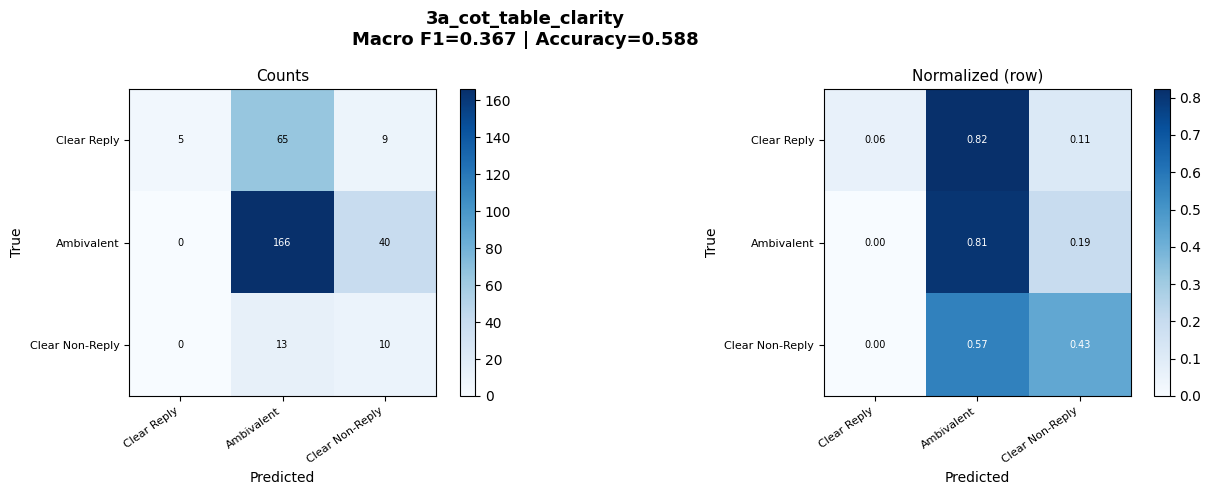

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3a_cot_table_clarity_confusion_matrix.png


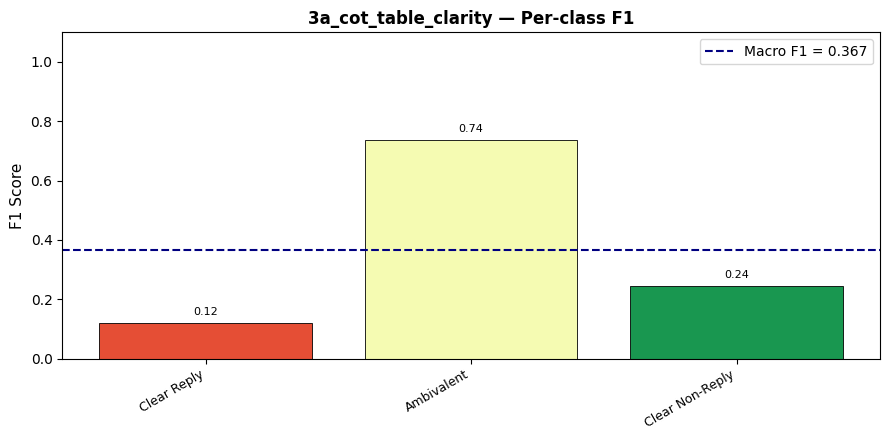

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3a_cot_table_clarity_f1_per_class.png


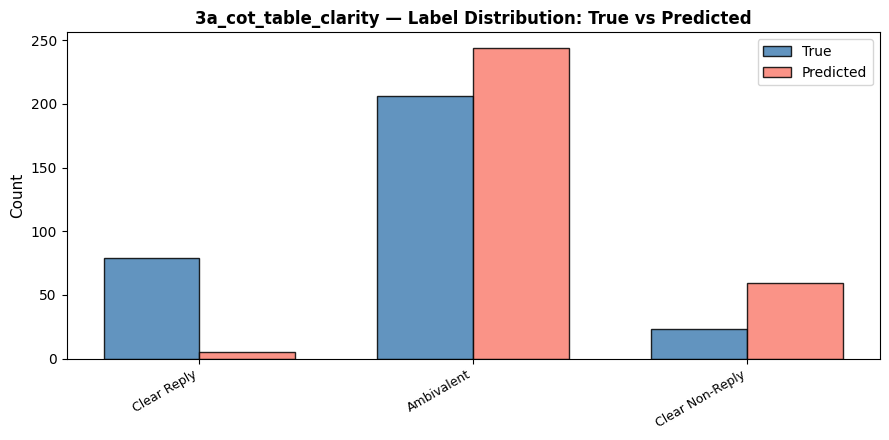

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3a_cot_table_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3a_cot_table_clarity_metrics.json


In [ ]:
print('POINT 3a — CoT + Table, 3-class clarity')
print(f'Samples: {len(df_test_1a)}  |  max_new_tokens: {MAX_NEW_TOKENS_COT3}')

csv_path_3a = str(SAVE_DIR / '3a_cot_table_clarity_predictions.csv')

df_res_3a = run_inference_cot_with_checkpoint(
    df            = df_test_1a,
    system_prompt = SYSTEM_3A,
    label_col     = 'clarity_label',
    valid_labels  = CLARITY_LABELS,
    exp_name      = '3a_cot_table_clarity',
    csv_path      = csv_path_3a,
    max_new_tokens= MAX_NEW_TOKENS_COT3,
)

print(f'Predictions loaded/saved from -> {csv_path_3a}')

if len(df_res_3a) == len(df_test_1a):
    metrics_3a = evaluate_and_plot(
        df_results   = df_res_3a,
        valid_labels = CLARITY_LABELS,
        exp_name     = '3a_cot_table_clarity',
        save_dir     = SAVE_DIR,
    )
else:
    print(f'[!] Inference incomplete ({len(df_res_3a)}/{len(df_test_1a)}). Re-run to continue.')

POINT 3b — CoT + Table, 9-class evasion (majority-voted ground truth)
Samples: 308  |  max_new_tokens: 400
[3b_cot_table_evasion] Checkpoint found: skipping 308 rows.


3b_cot_table_evasion: 100%|██████████| 308/308 [00:00<00:00, 22278.96it/s]

Predictions loaded/saved from -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3b_cot_table_evasion_predictions.csv

  3b_cot_table_evasion
  Total samples  : 308
  Parse errors   : 1  (0.3%)
  Valid samples  : 307
  Accuracy       : 0.1661
  Macro F1       : 0.1546
  Weighted F1    : 0.1605

                     precision    recall  f1-score   support

           Explicit       0.45      0.11      0.18        79
           Implicit       0.50      0.02      0.03        66
            General       0.43      0.09      0.15        65
Partial/half-answer       0.00      0.00      0.00         4
            Dodging       0.29      0.38      0.33        50
         Deflection       0.07      0.45      0.12        20
Declining to answer       0.05      0.27      0.09        11
   Claims ignorance       0.30      0.38      0.33         8
      Clarification       0.11      0.25      0.15         4

          micro avg       0.17      0.17      0.17       307
          macro avg     

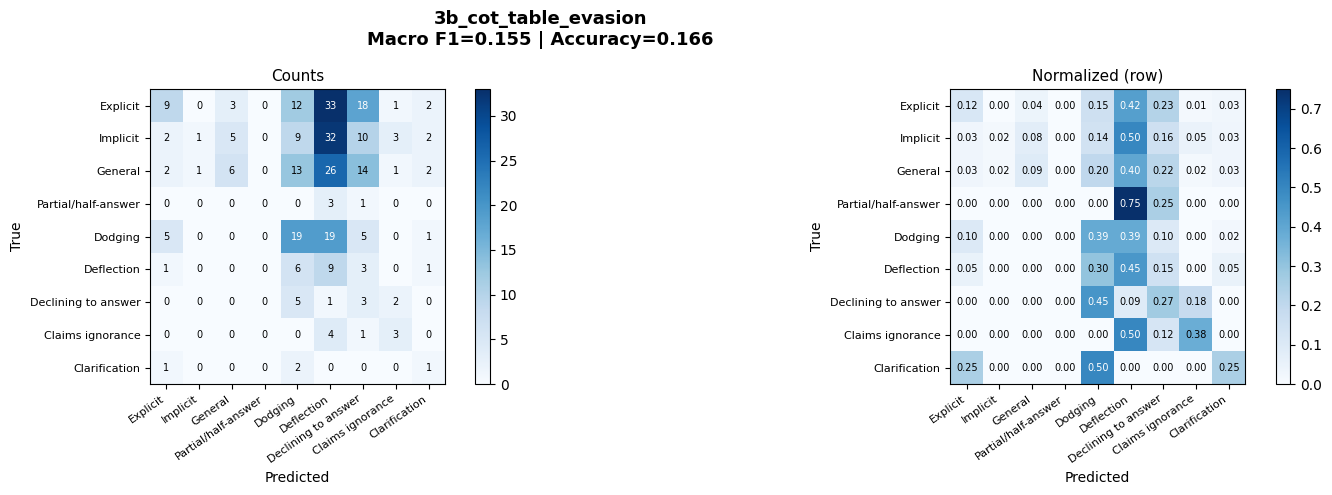

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3b_cot_table_evasion_confusion_matrix.png


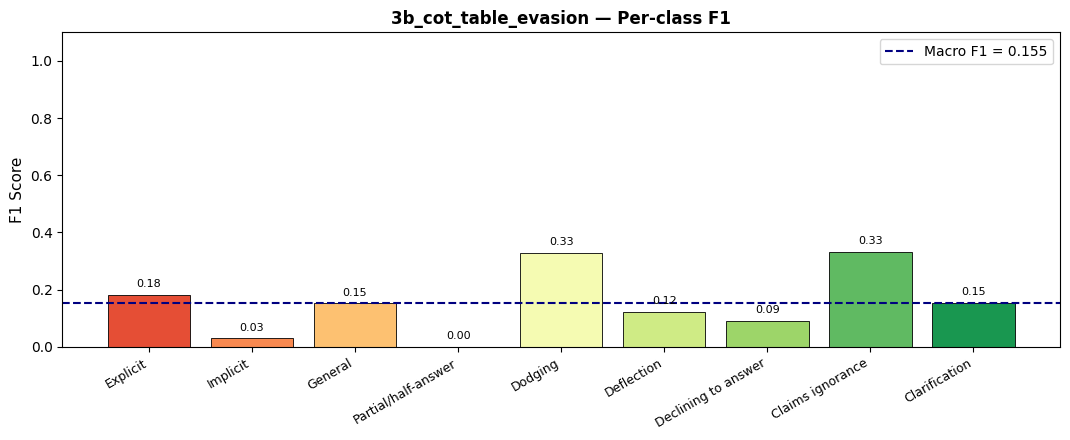

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3b_cot_table_evasion_f1_per_class.png


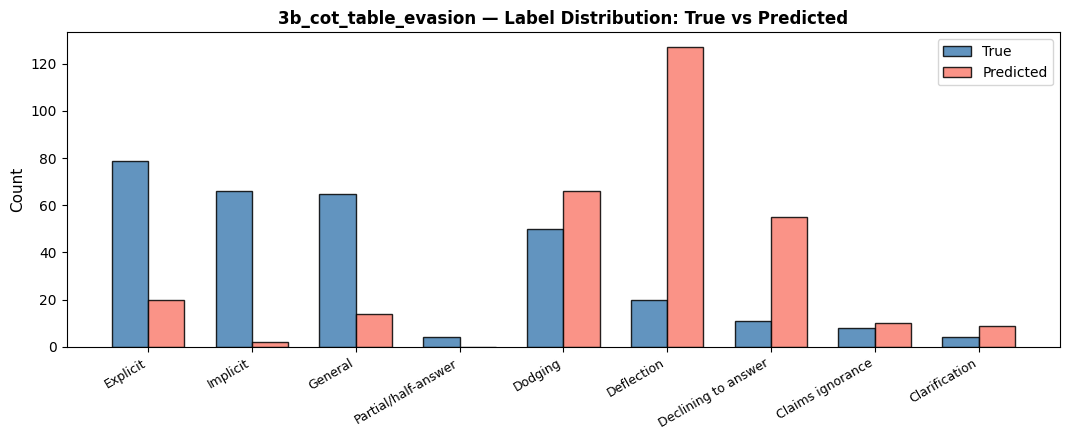

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3b_cot_table_evasion_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3b_cot_table_evasion_metrics.json


In [ ]:
print('POINT 3b — CoT + Table, 9-class evasion (majority-voted ground truth)')
print(f'Samples: {len(df_test_1b)}  |  max_new_tokens: {MAX_NEW_TOKENS_COT3}')

csv_path_3b = str(SAVE_DIR / '3b_cot_table_evasion_predictions.csv')

df_res_3b = run_inference_cot_with_checkpoint(
    df            = df_test_1b,
    system_prompt = SYSTEM_3B,
    label_col     = 'evasion_majority',
    valid_labels  = EVASION_LABELS,
    exp_name      = '3b_cot_table_evasion',
    csv_path      = csv_path_3b,
    max_new_tokens= MAX_NEW_TOKENS_COT3,
)

print(f'Predictions loaded/saved from -> {csv_path_3b}')

if len(df_res_3b) == len(df_test_1b):
    metrics_3b = evaluate_and_plot(
        df_results   = df_res_3b,
        valid_labels = EVASION_LABELS,
        exp_name     = '3b_cot_table_evasion',
        save_dir     = SAVE_DIR,
    )
else:
    print(f'[!] Inference incomplete ({len(df_res_3b)}/{len(df_test_1b)}). Re-run to continue.')

## 9 · Point 4 — CoT + Table + RAG

Extends Point 3 by injecting two types of dynamic context into the **user message**
(the system prompt stays the same as Point 3):

- **Wikipedia RAG**: brief summaries of named entities found in the question.
- **Question-type heuristics**: a hint about what a genuine answer should look like
  (e.g. a yes/no question expects a short direct answer).

> `wikipedia-api` is installed in the Colab setup cell.

In [ ]:
import re
import wikipediaapi

# In-memory cache to avoid duplicate Wikipedia calls
_wiki_cache: dict = {}

wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='CLARITY-SemEval/1.0 (research project)',
)

# Known political figures as fallback entity candidates
KNOWN_POLITICAL_FIGURES = {
    'Bush', 'George W. Bush', 'George Bush',
    'Obama', 'Barack Obama',
    'Clinton', 'Bill Clinton',
    'Trump', 'Donald Trump',
    'Blair', 'Tony Blair',
    'Putin', 'Vladimir Putin',
    'Kim Jong', 'Kim Jong-il', 'Kim Jong-un',
    'Hu Jintao', 'Koizumi',
}


def extract_entities(question: str) -> list:
    """
    Extract named entity candidates from a question using simple capitalisation
    heuristics. Returns up to 5 unique candidates.
    """
    words = question.strip().split()
    if len(words) <= 1:
        return []
    candidates = []
    i = 1  # skip first word (often capitalised as sentence start)
    while i < len(words):
        word = re.sub(r'[^\w\s]', '', words[i])
        if word and word[0].isupper() and len(word) > 1:
            entity = word
            if i + 1 < len(words):
                nw = re.sub(r'[^\w\s]', '', words[i+1])
                if nw and nw[0].isupper():
                    entity = word + ' ' + nw
                    if i + 2 < len(words):
                        nw2 = re.sub(r'[^\w\s]', '', words[i+2])
                        if nw2 and nw2[0].isupper():
                            entity = entity + ' ' + nw2
            candidates.append(entity)
        i += 1
    seen = set()
    unique = []
    for c in candidates:
        if c not in seen:
            seen.add(c)
            unique.append(c)
    return unique[:5]


def fetch_wikipedia_summary(entity: str, sentences: int = 3) -> str:
    """Fetch the first `sentences` sentences of a Wikipedia article. Cached."""
    if entity in _wiki_cache:
        return _wiki_cache[entity]
    try:
        page = wiki.page(entity)
        if page.exists():
            parts = page.summary.split('. ')
            short = '. '.join(parts[:sentences]).strip()
            if not short.endswith('.'):
                short += '.'
            _wiki_cache[entity] = short
            return short
        _wiki_cache[entity] = None
        return None
    except Exception:
        _wiki_cache[entity] = None
        return None


def build_rag_context(question: str, max_chars: int = 600) -> str:
    """
    Build a RAG context block for a question by fetching Wikipedia summaries
    for extracted entities. Returns empty string if no context is found.
    """
    entities = extract_entities(question)
    if not entities:
        return ''
    parts = []
    total = 0
    for entity in entities:
        if total >= max_chars:
            break
        summary = fetch_wikipedia_summary(entity)
        if summary:
            snippet = f'[{entity}]: {summary}'
            parts.append(snippet)
            total += len(snippet)
    if not parts:
        return ''
    return 'BACKGROUND CONTEXT (from Wikipedia):\n' + '\n'.join(parts)


print('RAG module defined.')
# Quick test
test_q = 'Will you invite them to the White House to negotiate on the jobs bill?'
print(f'Test entities: {extract_entities(test_q)}')
ctx = build_rag_context(test_q)
print(f'RAG context:\n{ctx if ctx else "(none found)"}')

RAG module defined.
Test entities: ['White House', 'House']
RAG context:
BACKGROUND CONTEXT (from Wikipedia):
[White House]: The White House is the official residence and workplace of the president of the United States. Located at 1600 Pennsylvania Avenue NW in Washington, D.C., it has served as the residence of every U.S. president since John Adams in 1800 when the national capital was moved from Philadelphia.
[House]: A house is a single-unit residential building. It may range in complexity from a rudimentary hut to a complex structure of wood, masonry, concrete or other material, outfitted with plumbing, electrical, and heating, ventilation, and air conditioning systems. Houses use a range of different roofing systems to keep precipitation such as rain from getting into the dwelling space.


In [ ]:
def classify_question_type(question: str) -> dict:
    """
    Heuristically classify a question into a type and return a prompt hint.

    Returns:
        dict with keys: question_type, expected_length, complexity_note.
    """
    q = re.sub(r'\s+', ' ', question.lower().strip())

    if re.search(r'^(will you|would you|are you|do you|did you|have you|can you|could you|is it|was it)', q):
        return {'question_type': 'yes_no', 'expected_length': 'short',
                'complexity_note': 'This is a YES/NO question. A genuine reply should be concise and direct. '
                'A long answer that never says yes or no is likely evasive.'}
    if re.search(r'^(what (is|was|are|were)|which|name|list)', q):
        return {'question_type': 'factual', 'expected_length': 'short_to_medium',
                'complexity_note': 'This is a FACTUAL question expecting a specific piece of information. '
                'A vague or general answer likely fails to provide what was asked.'}
    if re.search(r'^(why|how come|what (made|caused|led))', q):
        return {'question_type': 'why', 'expected_length': 'medium',
                'complexity_note': 'This is a WHY question. A genuine reply should explain a reason or cause. '
                'An answer that describes consequences without stating the reason is evasive.'}
    if re.search(r'^(when|what (date|time|year|month))', q):
        return {'question_type': 'when', 'expected_length': 'very_short',
                'complexity_note': 'This is a WHEN question expecting a time reference. '
                'Any answer without a date, timeframe, or temporal reference is evasive.'}
    if re.search(r'^(who|whom)', q):
        return {'question_type': 'who', 'expected_length': 'short',
                'complexity_note': 'This is a WHO question expecting a person or group to be named. '
                'An answer that discusses actions without naming anyone is evasive.'}
    if re.search(r'^(how (many|much|often|long))', q):
        return {'question_type': 'quantitative', 'expected_length': 'short',
                'complexity_note': 'This is a QUANTITATIVE question expecting a number or measurable answer. '
                'A qualitative answer without any figure is likely evasive.'}
    if re.search(r'^(do you think|what do you think|what is your|how do you feel|would you say)', q):
        return {'question_type': 'opinion', 'expected_length': 'medium',
                'complexity_note': 'This is an OPINION question. The politician is expected to take a position. '
                'An answer that discusses the topic without taking any stance is evasive.'}
    return {'question_type': 'open', 'expected_length': 'medium',
            'complexity_note': 'Evaluate whether the answer provides the specific information the question is asking for, '
            'regardless of its length.'}


print('Question-type heuristics defined.')

Question-type heuristics defined.


In [ ]:
def build_user_message_p4(question: str, answer: str) -> str:
    """
    Build the user message for Point 4:
    RAG context + question-type hint + question + answer.
    """
    rag_ctx    = build_rag_context(question)
    q_info     = classify_question_type(question)
    parts      = []
    if rag_ctx:
        parts.append(rag_ctx)
        parts.append('')
    parts.append(f"QUESTION TYPE: {q_info['question_type'].upper()}")
    parts.append(f"RESPONSE EXPECTATION: {q_info['complexity_note']}")
    parts.append('')
    parts.append(f'QUESTION: {question}')
    parts.append(f'\nANSWER: {answer}')
    return '\n'.join(parts)


def predict_cot_p4(system_prompt: str, question: str, answer: str,
                   max_new_tokens: int = MAX_NEW_TOKENS_COT4) -> tuple:
    """Point 4 variant of predict_cot: uses build_user_message_p4."""
    user_msg   = build_user_message_p4(question, answer)
    messages   = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': user_msg},
    ]
    prompt_str = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    inputs = tokenizer(
        prompt_str, return_tensors='pt', add_special_tokens=False
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            temperature=TEMPERATURE,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated_ids = out[0][inputs['input_ids'].shape[-1]:]
    raw           = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    steps         = re.findall(r'<step\d>(.*?)</step\d>', raw, re.DOTALL)
    reasoning     = ' | '.join(s.strip() for s in steps) if steps else ''
    return raw, reasoning


def run_inference_cot_p4_with_checkpoint(df, system_prompt, label_col,
                                          valid_labels, exp_name, csv_path, max_new_tokens=450):
    """
    Point 4 variant of run_inference_cot_with_checkpoint.
    Adds rag_context and question_type columns to the output CSV.
    """
    import os
    if os.path.exists(csv_path):
        df_saved = pd.read_csv(csv_path)
        processed = set(df_saved['question'].astype(str))
        print(f'[{exp_name}] Checkpoint found: skipping {len(processed)} rows.')
        mode, header = 'a', False
    else:
        processed = set()
        print(f'[{exp_name}] No checkpoint: starting from scratch.')
        mode, header = 'w', True
    try:
        for _, row in tqdm(df.iterrows(), total=len(df), desc=exp_name):
            q = str(row['question'])
            if q in processed:
                continue
            a       = str(row['interview_answer'])
            true    = str(row[label_col])
            rag_ctx = build_rag_context(q)
            q_info  = classify_question_type(q)
            try:
                raw, reasoning = predict_cot_p4(system_prompt, q, a, max_new_tokens=max_new_tokens)
                pred = parse_cot_label(raw, valid_labels)
            except Exception as e:
                raw, reasoning, pred = f'ERROR: {e}', '', 'PARSE_ERROR'
            record = {
                'question':       q,
                'answer_snippet': a[:150],
                'true_label':     true,
                'pred_label':     pred,
                'reasoning':      reasoning,
                'rag_context':    rag_ctx[:200] if rag_ctx else '',
                'question_type':  q_info['question_type'],
                'raw_output':     raw,
            }
            pd.DataFrame([record]).to_csv(csv_path, mode=mode, header=header, index=False)
            mode, header = 'a', False
    except KeyboardInterrupt:
        print('\n[!] Interrupted. Progress saved to CSV.')
    return pd.read_csv(csv_path)


print('Point 4 functions defined.')

Point 4 functions defined.


POINT 4a — CoT + Table + RAG, 3-class clarity
Samples: 308  |  max_new_tokens: 450
[4a_cot_rag_clarity] Checkpoint found: skipping 308 rows.


4a_cot_rag_clarity: 100%|██████████| 308/308 [00:00<00:00, 21707.68it/s]

Predictions loaded/saved from -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4a_cot_rag_clarity_predictions.csv

  4a_cot_rag_clarity
  Total samples  : 308
  Parse errors   : 0  (0.0%)
  Valid samples  : 308
  Accuracy       : 0.5779
  Macro F1       : 0.3565
  Weighted F1    : 0.5293

                 precision    recall  f1-score   support

    Clear Reply       0.80      0.05      0.10        79
     Ambivalent       0.67      0.80      0.73       206
Clear Non-Reply       0.17      0.43      0.25        23

       accuracy                           0.58       308
      macro avg       0.55      0.43      0.36       308
   weighted avg       0.67      0.58      0.53       308



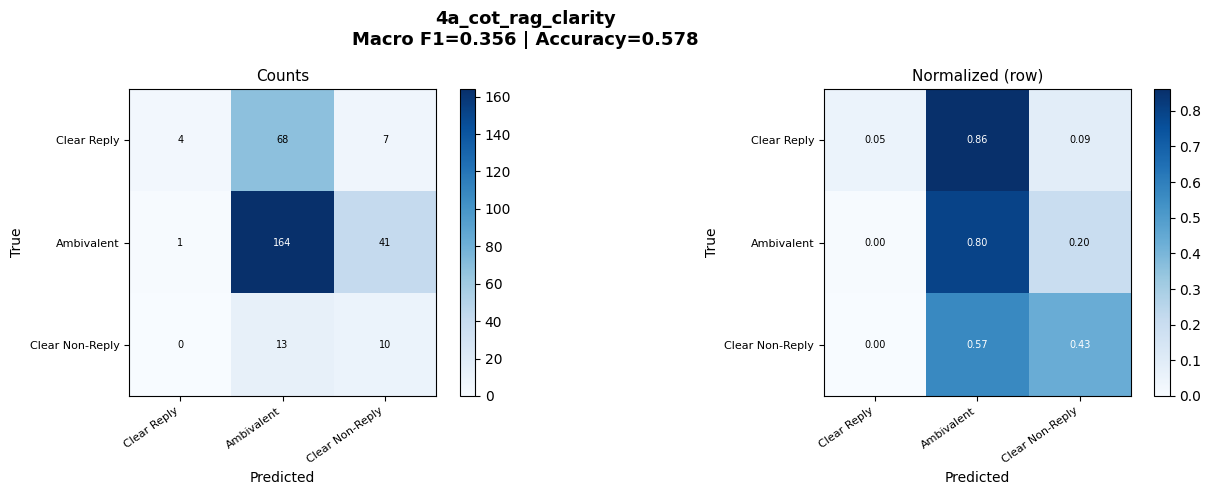

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4a_cot_rag_clarity_confusion_matrix.png


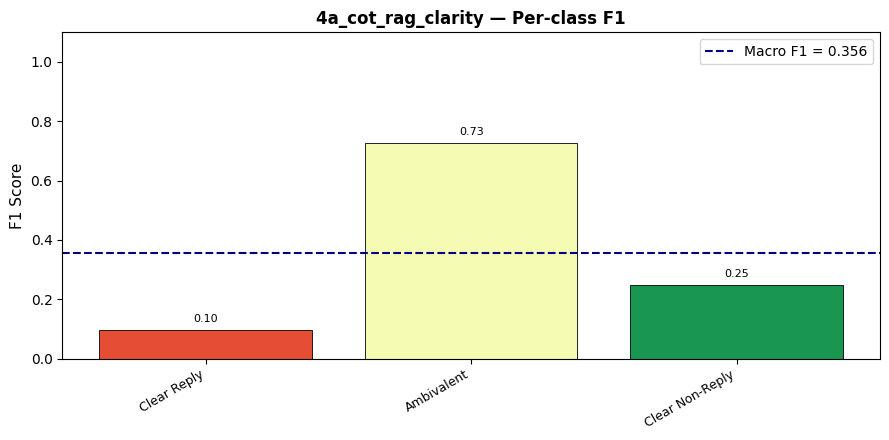

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4a_cot_rag_clarity_f1_per_class.png


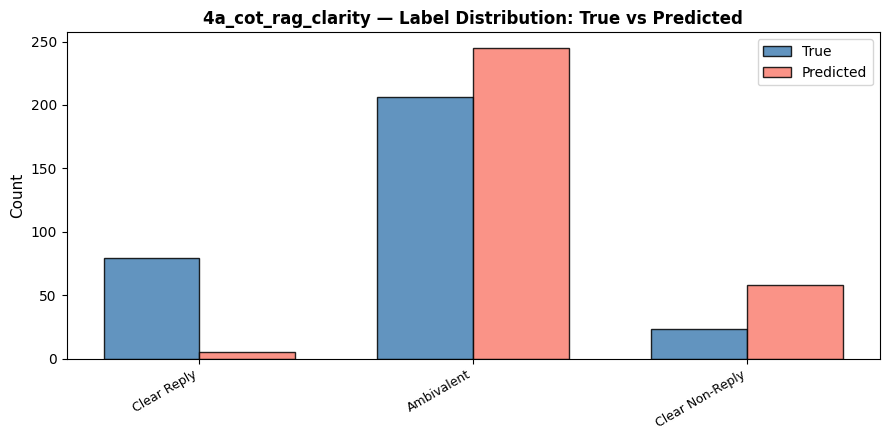

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4a_cot_rag_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4a_cot_rag_clarity_metrics.json


In [ ]:
print('POINT 4a — CoT + Table + RAG, 3-class clarity')
print(f'Samples: {len(df_test_1a)}  |  max_new_tokens: {MAX_NEW_TOKENS_COT4}')

csv_path_4a = str(SAVE_DIR / '4a_cot_rag_clarity_predictions.csv')

df_res_4a = run_inference_cot_p4_with_checkpoint(
    df            = df_test_1a,
    system_prompt = SYSTEM_3A,
    label_col     = 'clarity_label',
    valid_labels  = CLARITY_LABELS,
    exp_name      = '4a_cot_rag_clarity',
    csv_path      = csv_path_4a,
    max_new_tokens= MAX_NEW_TOKENS_COT4,
)

print(f'Predictions loaded/saved from -> {csv_path_4a}')

if len(df_res_4a) == len(df_test_1a):
    metrics_4a = evaluate_and_plot(
        df_results   = df_res_4a,
        valid_labels = CLARITY_LABELS,
        exp_name     = '4a_cot_rag_clarity',
        save_dir     = SAVE_DIR,
    )
else:
    print(f'[!] Inference incomplete ({len(df_res_4a)}/{len(df_test_1a)}). Re-run to continue.')

POINT 4b — CoT + Table + RAG, 9-class evasion (majority-voted ground truth)
Samples: 308  |  max_new_tokens: 450
[4b_cot_rag_evasion] Checkpoint found: skipping 308 rows.


4b_cot_rag_evasion: 100%|██████████| 308/308 [00:00<00:00, 22005.72it/s]

Predictions loaded/saved from -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4b_cot_rag_evasion_predictions.csv

  4b_cot_rag_evasion
  Total samples  : 308
  Parse errors   : 1  (0.3%)
  Valid samples  : 307
  Accuracy       : 0.1889
  Macro F1       : 0.1414
  Weighted F1    : 0.1623

                     precision    recall  f1-score   support

           Explicit       0.59      0.13      0.21        79
           Implicit       0.00      0.00      0.00        66
            General       0.29      0.14      0.19        65
Partial/half-answer       0.00      0.00      0.00         4
            Dodging       0.23      0.36      0.28        50
         Deflection       0.12      0.70      0.21        20
Declining to answer       0.11      0.55      0.18        11
   Claims ignorance       0.00      0.00      0.00         8
      Clarification       0.17      0.25      0.20         4

          micro avg       0.19      0.19      0.19       307
          macro avg       0.

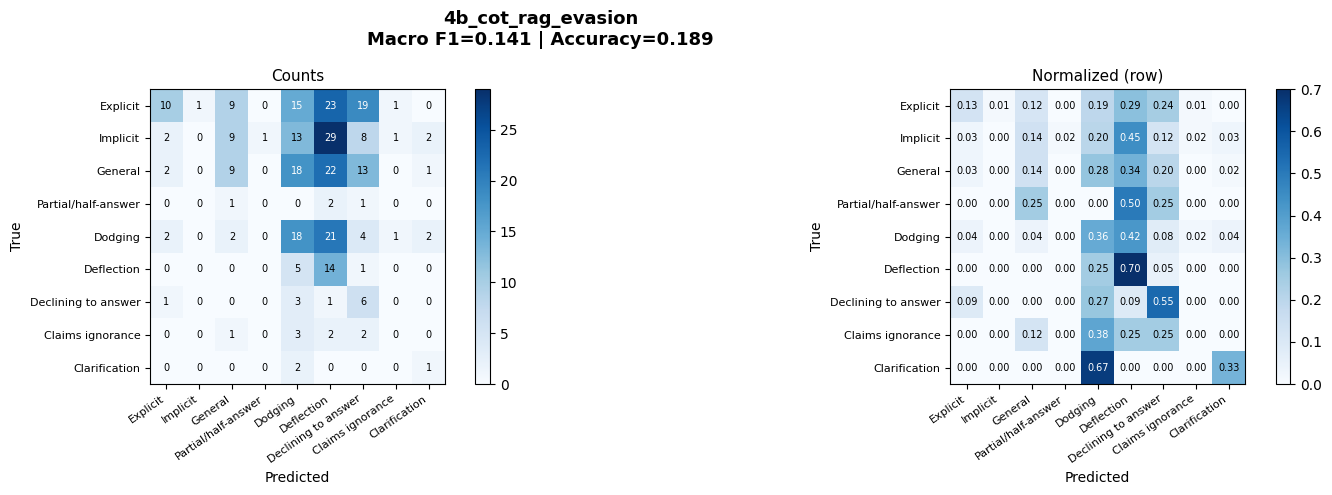

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4b_cot_rag_evasion_confusion_matrix.png


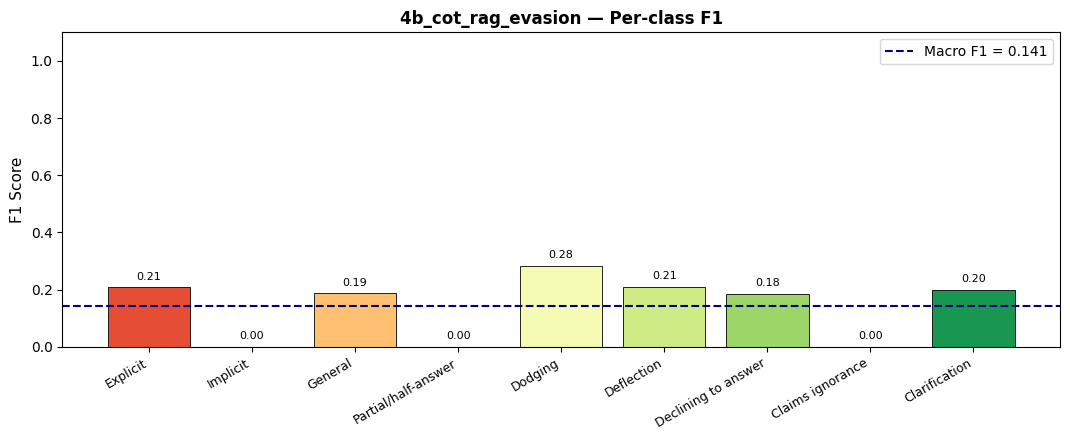

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4b_cot_rag_evasion_f1_per_class.png


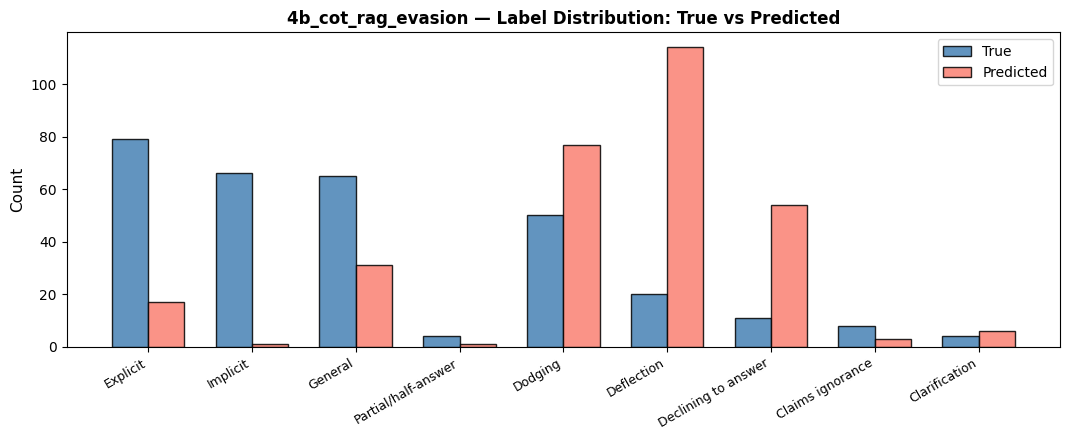

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4b_cot_rag_evasion_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4b_cot_rag_evasion_metrics.json


In [ ]:
print('POINT 4b — CoT + Table + RAG, 9-class evasion (majority-voted ground truth)')
print(f'Samples: {len(df_test_1b)}  |  max_new_tokens: {MAX_NEW_TOKENS_COT4}')

csv_path_4b = str(SAVE_DIR / '4b_cot_rag_evasion_predictions.csv')

df_res_4b = run_inference_cot_p4_with_checkpoint(
    df            = df_test_1b,
    system_prompt = SYSTEM_3B,
    label_col     = 'evasion_majority',
    valid_labels  = EVASION_LABELS,
    exp_name      = '4b_cot_rag_evasion',
    csv_path      = csv_path_4b,
    max_new_tokens= MAX_NEW_TOKENS_COT4,
)

print(f'Predictions loaded/saved from -> {csv_path_4b}')

if len(df_res_4b) == len(df_test_1b):
    metrics_4b = evaluate_and_plot(
        df_results   = df_res_4b,
        valid_labels = EVASION_LABELS,
        exp_name     = '4b_cot_rag_evasion',
        save_dir     = SAVE_DIR,
    )
else:
    print(f'[!] Inference incomplete ({len(df_res_4b)}/{len(df_test_1b)}). Re-run to continue.')

Calcolo del mapping Evasion -> Clarity dai file CSV salvati...

  1c_zeroshot_evasion_to_clarity
  Total samples  : 308
  Parse errors   : 0  (0.0%)
  Valid samples  : 308
  Accuracy       : 0.6786
  Macro F1       : 0.4073
  Weighted F1    : 0.5842

                 precision    recall  f1-score   support

    Clear Reply       1.00      0.04      0.07        79
     Ambivalent       0.69      0.97      0.81       206
Clear Non-Reply       0.39      0.30      0.34        23

       accuracy                           0.68       308
      macro avg       0.69      0.44      0.41       308
   weighted avg       0.75      0.68      0.58       308



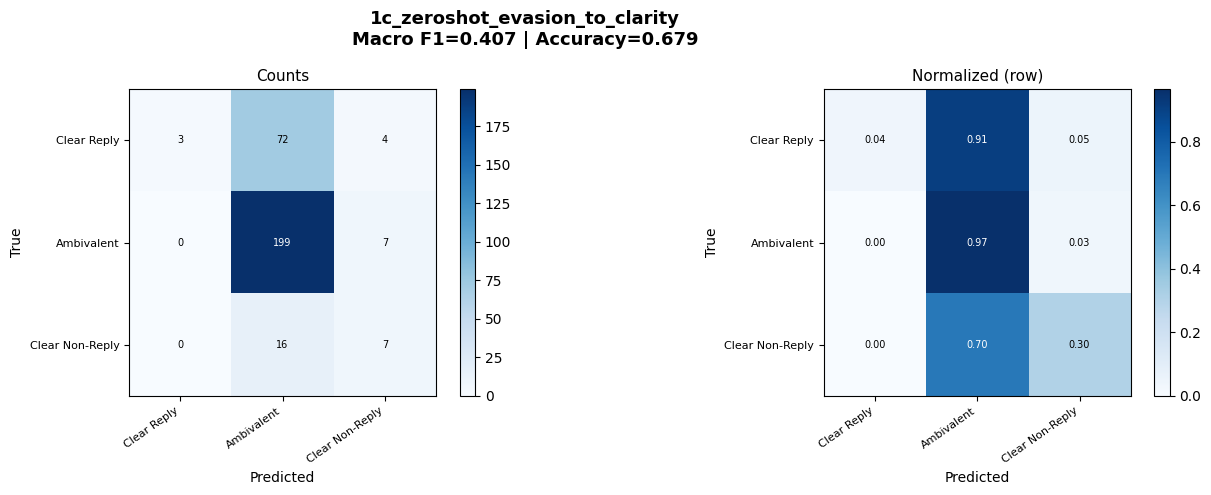

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1c_zeroshot_evasion_to_clarity_confusion_matrix.png


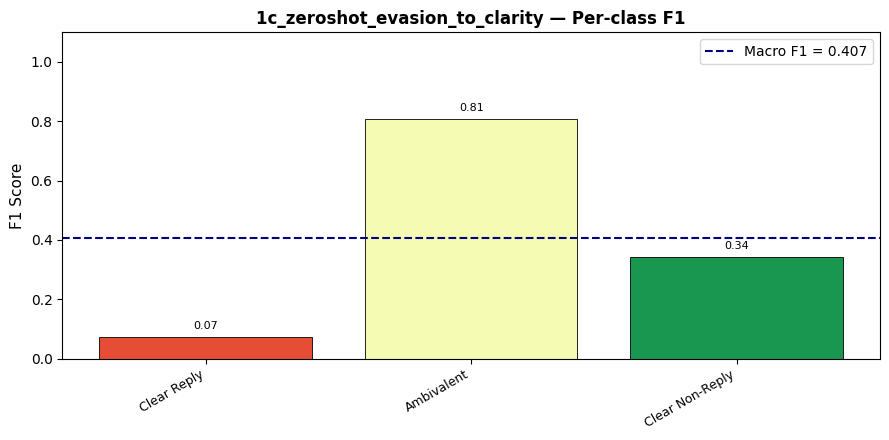

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1c_zeroshot_evasion_to_clarity_f1_per_class.png


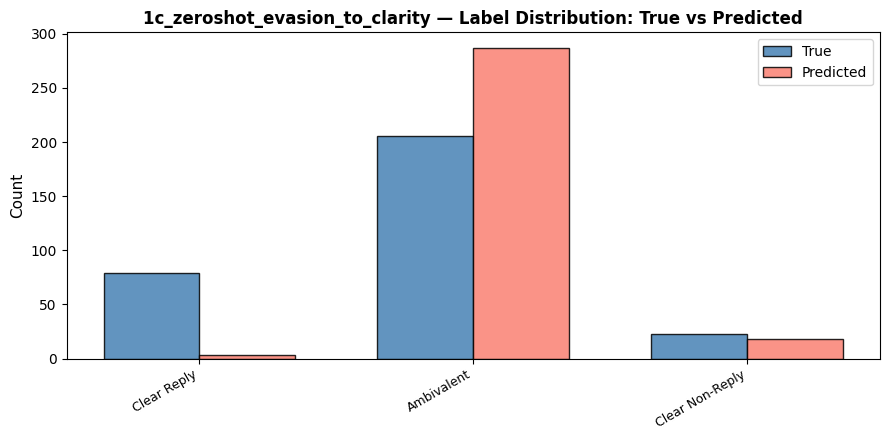

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1c_zeroshot_evasion_to_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/1c_zeroshot_evasion_to_clarity_metrics.json

  2c_cot_evasion_to_clarity
  Total samples  : 308
  Parse errors   : 1  (0.3%)
  Valid samples  : 307
  Accuracy       : 0.6808
  Macro F1       : 0.3972
  Weighted F1    : 0.5778

                 precision    recall  f1-score   support

    Clear Reply       1.00      0.03      0.05        79
     Ambivalent       0.69      0.98      0.81       205
Clear Non-Reply       0.46      0.26      0.33        23

       accuracy                           0.68       307
      macro avg       0.72      0.42      0.40       307
   weighted avg       0.75      0.68      0.58       307



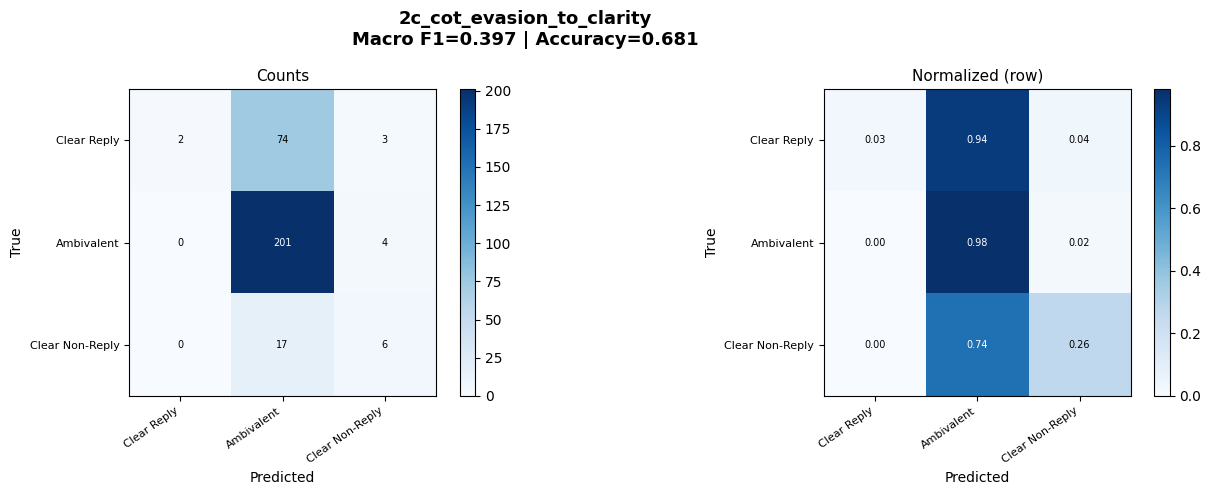

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2c_cot_evasion_to_clarity_confusion_matrix.png


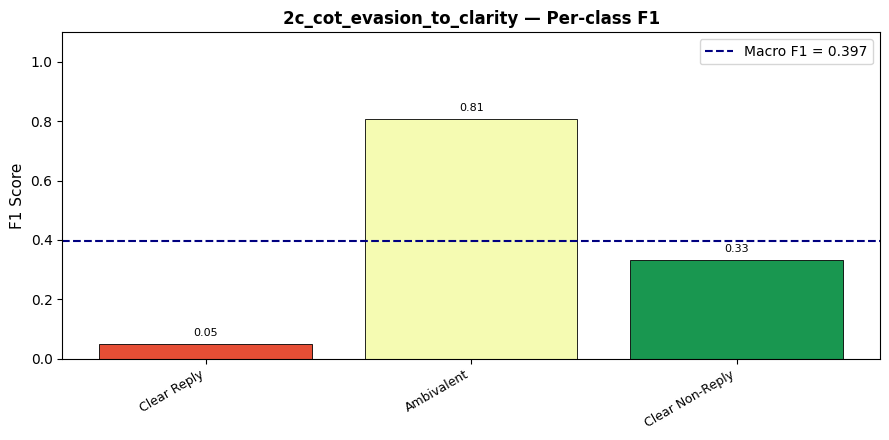

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2c_cot_evasion_to_clarity_f1_per_class.png


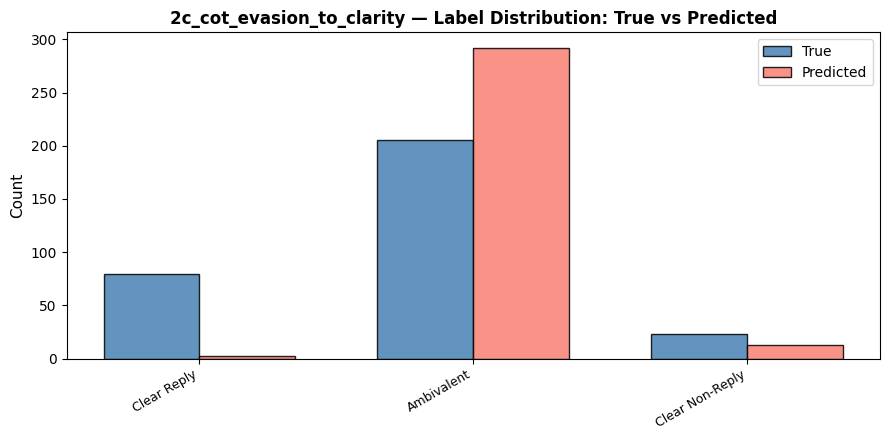

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2c_cot_evasion_to_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/2c_cot_evasion_to_clarity_metrics.json

  3c_cot_table_evasion_to_clarity
  Total samples  : 308
  Parse errors   : 5  (1.6%)
  Valid samples  : 303
  Accuracy       : 0.5545
  Macro F1       : 0.3716
  Weighted F1    : 0.5463

                 precision    recall  f1-score   support

    Clear Reply       0.45      0.12      0.18        78
     Ambivalent       0.71      0.74      0.73       202
Clear Non-Reply       0.14      0.43      0.21        23

       accuracy                           0.55       303
      macro avg       0.43      0.43      0.37       303
   weighted avg       0.60      0.55      0.55       303



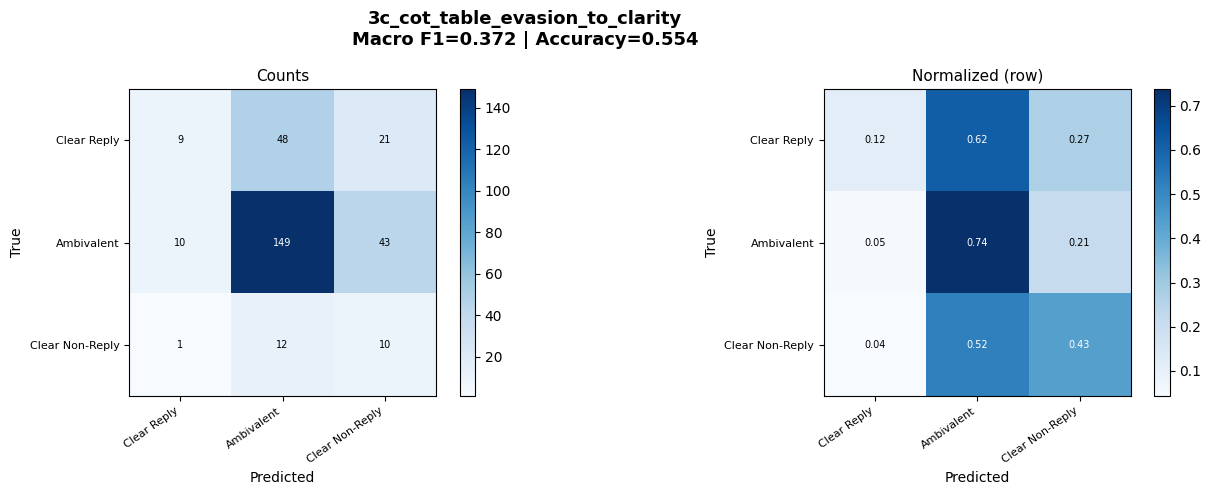

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3c_cot_table_evasion_to_clarity_confusion_matrix.png


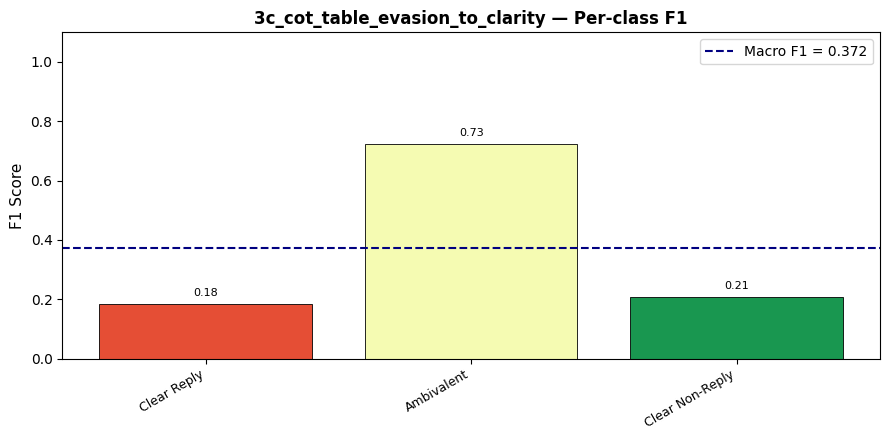

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3c_cot_table_evasion_to_clarity_f1_per_class.png


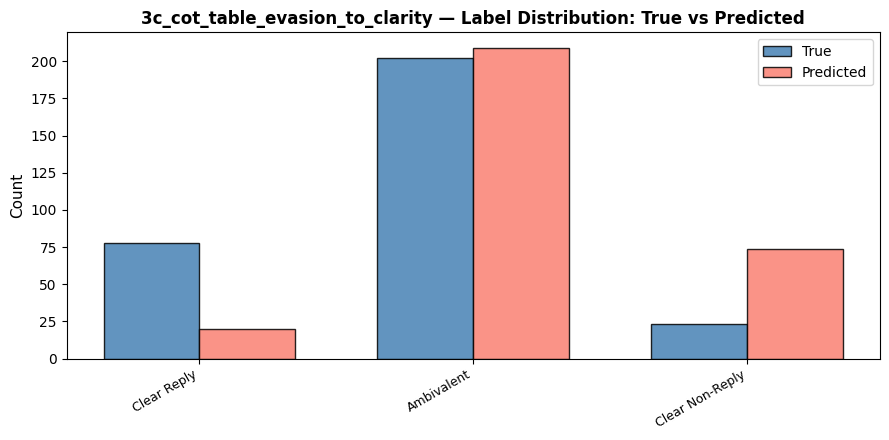

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3c_cot_table_evasion_to_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/3c_cot_table_evasion_to_clarity_metrics.json

  4c_cot_rag_evasion_to_clarity
  Total samples  : 308
  Parse errors   : 4  (1.3%)
  Valid samples  : 304
  Accuracy       : 0.6020
  Macro F1       : 0.3962
  Weighted F1    : 0.5836

                 precision    recall  f1-score   support

    Clear Reply       0.59      0.13      0.21        78
     Ambivalent       0.73      0.80      0.77       204
Clear Non-Reply       0.14      0.41      0.21        22

       accuracy                           0.60       304
      macro avg       0.49      0.45      0.40       304
   weighted avg       0.65      0.60      0.58       304



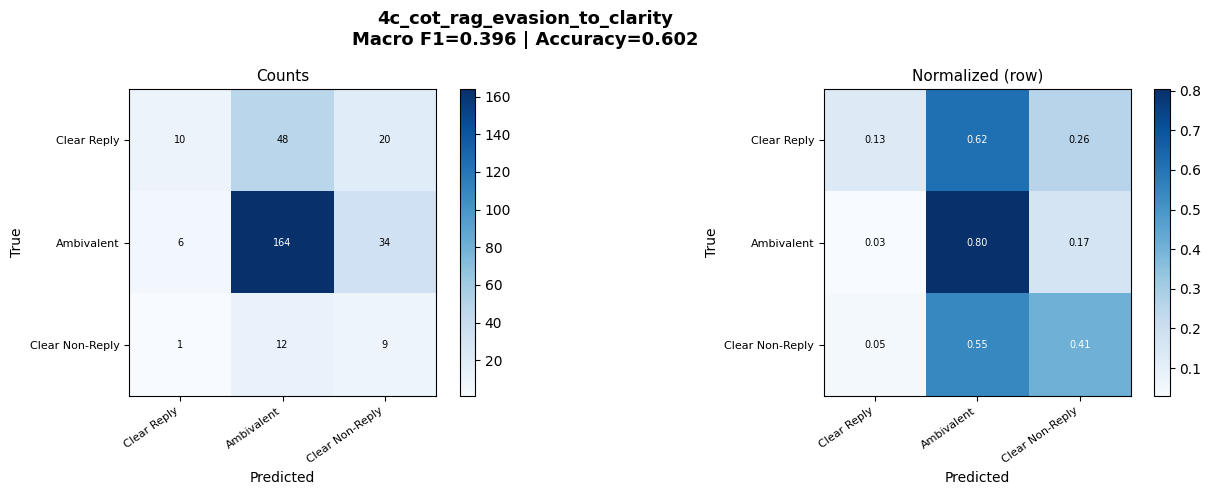

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4c_cot_rag_evasion_to_clarity_confusion_matrix.png


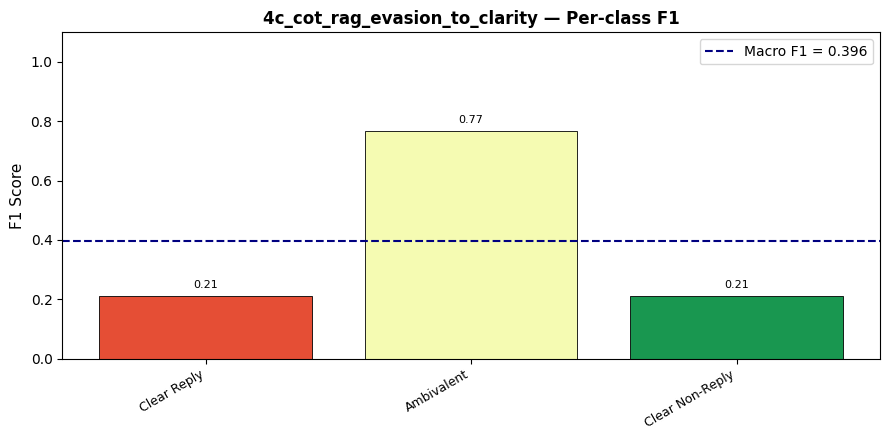

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4c_cot_rag_evasion_to_clarity_f1_per_class.png


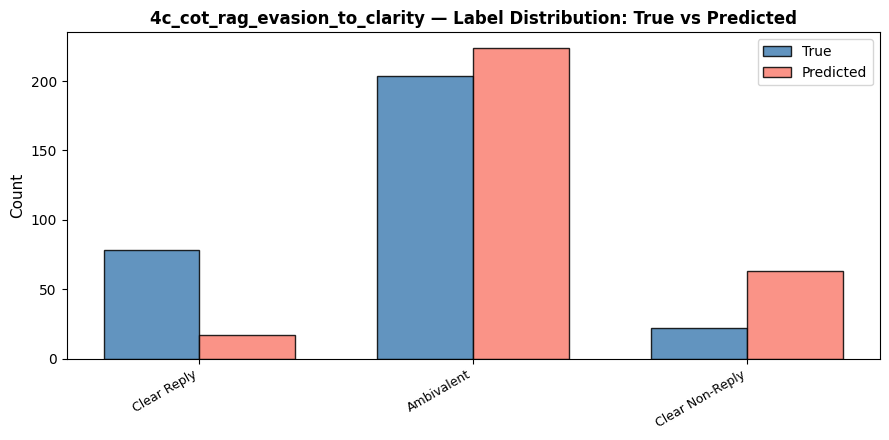

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4c_cot_rag_evasion_to_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/4c_cot_rag_evasion_to_clarity_metrics.json


In [ ]:
# ── MAPPING EVASION -> CLARITY (Punti 1c, 2c, 3c, 4c) ─────────────────────────
import pandas as pd

EVASION_TO_CLARITY_MAP = {
    'Explicit': 'Clear Reply',
    'Implicit': 'Ambivalent',
    'General': 'Ambivalent',
    'Partial/half-answer': 'Ambivalent',
    'Dodging': 'Ambivalent',
    'Deflection': 'Ambivalent',
    'Declining to answer': 'Clear Non-Reply',
    'Claims ignorance': 'Clear Non-Reply',
    'Clarification': 'Clear Non-Reply',
}

def apply_mapping_and_evaluate(evasion_csv_name, exp_name):
    # Carica le predizioni evasion salvate per non rieseguire il modello
    csv_path = SAVE_DIR / evasion_csv_name
    if not csv_path.exists():
        print(f"File {csv_path} non trovato. Assicurati che l'inferenza sia stata completata.")
        return None

    df_res = pd.read_csv(csv_path)

    # Applica il mapping
    df_res['pred_label'] = df_res['pred_label'].apply(
        lambda x: EVASION_TO_CLARITY_MAP.get(x, 'PARSE_ERROR')
    )
    df_res['true_label'] = df_res['true_label'].apply(
        lambda x: EVASION_TO_CLARITY_MAP.get(x, 'PARSE_ERROR')
    )

    # Salva il nuovo CSV mappato
    mapped_csv_path = SAVE_DIR / f'{exp_name}_predictions.csv'
    df_res.to_csv(mapped_csv_path, index=False)

    # Valuta usando la funzione già definita nel notebook
    metrics = evaluate_and_plot(
        df_results=df_res,
        valid_labels=CLARITY_LABELS,
        exp_name=exp_name,
        save_dir=SAVE_DIR,
    )
    return metrics

print('Calcolo del mapping Evasion -> Clarity dai file CSV salvati...')
metrics_1c = apply_mapping_and_evaluate('1b_zeroshot_evasion_predictions.csv', '1c_zeroshot_evasion_to_clarity')
metrics_2c = apply_mapping_and_evaluate('2b_cot_evasion_predictions.csv', '2c_cot_evasion_to_clarity')
metrics_3c = apply_mapping_and_evaluate('3b_cot_table_evasion_predictions.csv', '3c_cot_table_evasion_to_clarity')
metrics_4c = apply_mapping_and_evaluate('4b_cot_rag_evasion_predictions.csv', '4c_cot_rag_evasion_to_clarity')

## 10 · Point 5 — CoT + Taxonomy Table + Tone

In [ ]:
SYSTEM_5A = """You are an expert political science annotator tasked with analyzing the clarity of politicians' answers during interviews.
You must classify the response into exactly one of three categories: Clear Reply, Ambivalent, or Clear Non-Reply.

CRITICAL ADDITION: The answer has been pre-analyzed with a rhetorical tone label (Assertive, Guarded, or Dismissive). Use this tone as a strong hint for determining the conversational structure. For example, a Guarded tone often indicates an Ambivalent or evasive response.

Use the following definitions as your reference:
+----------------------+-------------------------------------------------------------------------------+
| Class                | Definition                                                                    |
+======================+===============================================================================+
| Clear Reply          | The answer explicitly or implicitly provides the specific information         |
|                      | requested by the journalist. It addresses the core of the question directly.  |
+----------------------+-------------------------------------------------------------------------------+
| Ambivalent           | The answer engages with the topic but fails to provide the specific           |
|                      | information requested. It may be too general, answer only part of the         |
|                      | question, or pivot to a tangentially related point (deflection).              |
+----------------------+-------------------------------------------------------------------------------+
| Clear Non-Reply      | The answer completely fails to engage with the core topic of the question.    |
|                      | This includes refusing to answer, claiming ignorance, or dodging the          |
|                      | question entirely by shifting to a completely unrelated topic.                |
+----------------------+-------------------------------------------------------------------------------+

Think step by step:

<step1>
What specific information is the journalist requesting?
Identify the core question in one sentence.
</step1>

<step2>
Analyze the answer's tone. How does the tone (Assertive, Guarded, Dismissive) affect the likelihood of the answer being a direct reply or an evasion?
</step2>

<step3>
What does the answer actually do?
- Does it engage with the question topic at all?
- Does it provide the specific information requested?
Describe concretely what the answer does, then match it to the definitions above.
</step3>

Output the final label inside <label> tags.
Choose exactly ONE of: Clear Reply | Ambivalent | Clear Non-Reply

Output format:
<step1>...</step1>
<step2>...</step2>
<step3>...</step3>
<label>YOUR LABEL HERE</label>"""

SYSTEM_5B = """You are an expert political science annotator tasked with analyzing how politicians evade questions.
You must classify the response into exactly one of nine evasion techniques.

CRITICAL ADDITION: The answer has been pre-analyzed with a rhetorical tone label (Assertive, Guarded, or Dismissive). Use this tone as a strong hint for determining the conversational structure. For example, a Guarded tone often indicates an Ambivalent or evasive response.

Use the following taxonomy as your absolute reference:
+----------------------+-------------------------------------------------------------------------------+
| Technique            | Definition and Example                                                        |
+======================+===============================================================================+
|                      | *** CLEAR REPLY ***                                                          |
+----------------------+-------------------------------------------------------------------------------+
| Explicit             | The information requested is directly and clearly provided.                   |
|                      | Q: "Will you raise taxes?"                                                   |
|                      | A: "No, we will not raise taxes."                                            |
+----------------------+-------------------------------------------------------------------------------+
| Implicit             | The information is given but without being explicitly stated.                 |
|                      | Q: "Are you going to watch television?"                                      |
|                      | A: "What else is there to do?"                                               |
+----------------------+-------------------------------------------------------------------------------+
|                      | *** AMBIVALENT REPLY ***                                                     |
+----------------------+-------------------------------------------------------------------------------+
| General              | The information provided is too general or lacks the requested specificity.   |
|                      | Q: "What's your favourite film?"                                             |
|                      | A: "Fight Club, Filth and Hereditary"                                        |
+----------------------+-------------------------------------------------------------------------------+
| Partial/half-answer  | Offers only a specific component of the requested information.                |
|                      | Q: "Did you enjoy the film?"                                                 |
|                      | A: "The directing was great."                                                |
+----------------------+-------------------------------------------------------------------------------+
| Dodging              | Ignoring the question altogether, not even acknowledging it.                  |
|                      | Q: "Do you like my new dress?"                                               |
|                      | A: "We are late."                                                            |
+----------------------+-------------------------------------------------------------------------------+
| Deflection           | Starts on topic but shifts focus and makes a different point than asked.     |
|                      | Q: "Did you eat the last piece of pie?"                                      |
|                      | A: "I have to admit that was a great recipe, I always like chocolate chips." |
+----------------------+-------------------------------------------------------------------------------+
|                      | *** CLEAR NON-REPLY ***                                                      |
+----------------------+-------------------------------------------------------------------------------+
| Declining to answer  | Acknowledges the question but directly or indirectly refuses to answer.      |
|                      | Q: "Wouldn't you regard that as a defeat?"                                   |
|                      | A: "I am not going to prophesy what will happen."                            |
+----------------------+-------------------------------------------------------------------------------+
| Claims ignorance     | The answerer claims or admits not to know the answer themselves.              |
|                      | Q: "On what precise date did the government order the refit?"                 |
|                      | A: "I do not know that date. I will find out and let the House know."        |
+----------------------+-------------------------------------------------------------------------------+
| Clarification        | Does not provide the requested information and asks for clarification.        |
|                      | Q: "Was it your decision to release the fund?"                               |
|                      | A: "You mean the public fund?"                                               |
+----------------------+-------------------------------------------------------------------------------+

Think step by step:

<step1>
What specific information is the journalist requesting?
Identify the core question in one sentence.
</step1>

<step2>
Analyze the answer's tone. How does the tone (Assertive, Guarded, Dismissive) affect the likelihood of the answer being a direct reply or an evasion?
</step2>

<step3>
What does the answer actually do?
- Does it engage with the question topic at all?
- Does it provide the specific information requested?
Describe concretely what the answer does, then match it to the taxonomy above.
</step3>

Output the final label inside <label> tags.
Choose exactly ONE of: Explicit | Implicit | General | Partial/half-answer | Dodging | Deflection | Declining to answer | Claims ignorance | Clarification

Output format:
<step1>...</step1>
<step2>...</step2>
<step3>...</step3>
<label>YOUR LABEL HERE</label>"""

print(f'Point 5 prompts defined. MAX_NEW_TOKENS_COT3 = {MAX_NEW_TOKENS_COT3}')


Point 5 prompts defined. MAX_NEW_TOKENS_COT3 = 400


POINT 5a — CoT + Table + Tone, 3-class clarity
Samples: 308  |  max_new_tokens: 400
[5a_cot_tone_clarity] Checkpoint found: skipping 117 rows.


5a_cot_tone_clarity: 100%|██████████| 308/308 [1:24:03<00:00, 16.38s/it]


Predictions loaded/saved from -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5a_cot_tone_clarity_predictions.csv

  5a_cot_tone_clarity
  Total samples  : 308
  Parse errors   : 2  (0.6%)
  Valid samples  : 306
  Accuracy       : 0.6667
  Macro F1       : 0.3841
  Weighted F1    : 0.6093

                 precision    recall  f1-score   support

    Clear Reply       0.50      0.21      0.29        77
     Ambivalent       0.70      0.91      0.79       206
Clear Non-Reply       0.20      0.04      0.07        23

       accuracy                           0.67       306
      macro avg       0.47      0.39      0.38       306
   weighted avg       0.61      0.67      0.61       306



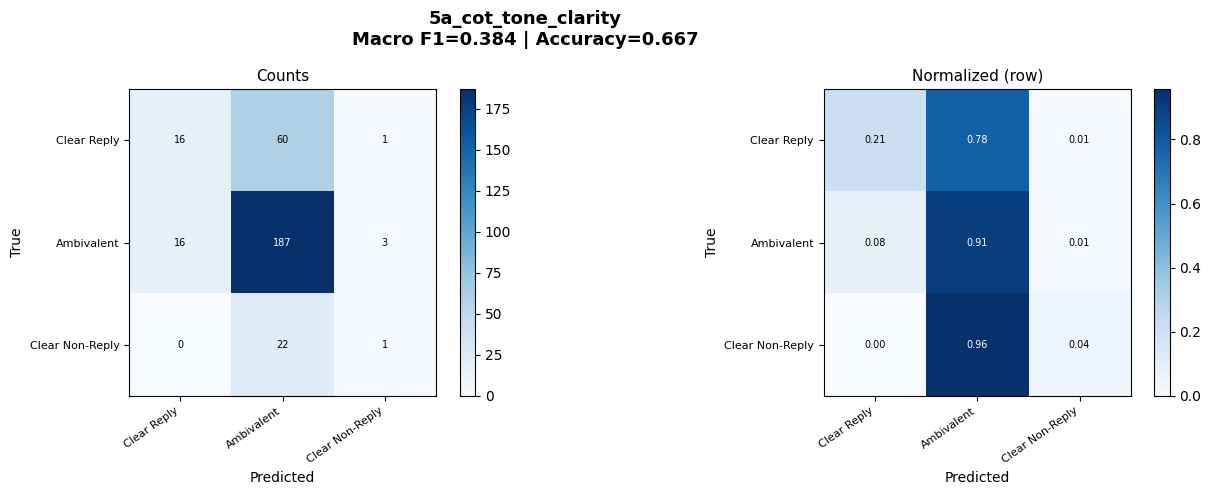

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5a_cot_tone_clarity_confusion_matrix.png


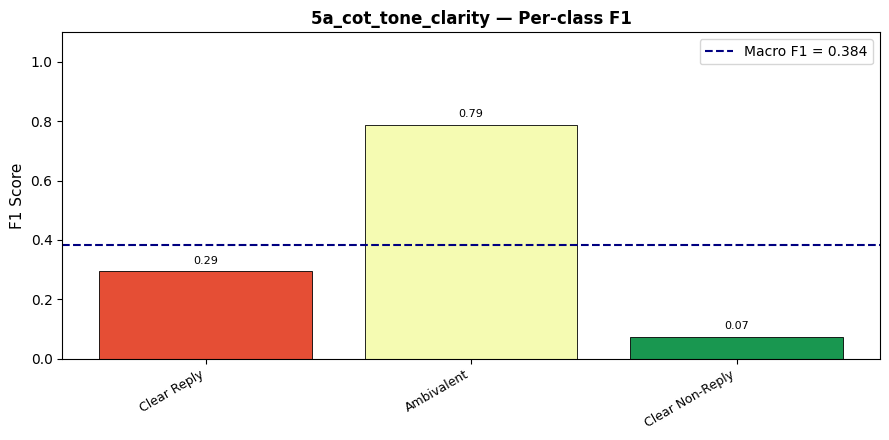

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5a_cot_tone_clarity_f1_per_class.png


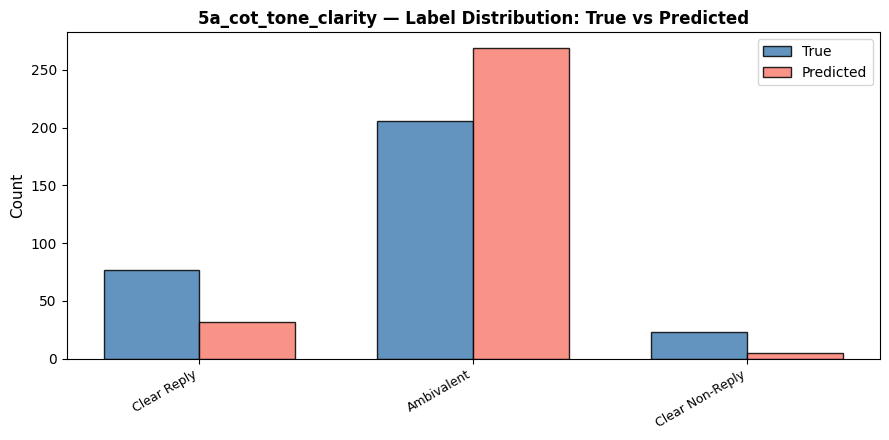

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5a_cot_tone_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5a_cot_tone_clarity_metrics.json


In [ ]:
print('POINT 5a — CoT + Table + Tone, 3-class clarity')
print(f'Samples: {len(df_test_1a_tone)}  |  max_new_tokens: {MAX_NEW_TOKENS_COT3}')

csv_path_5a = str(SAVE_DIR / '5a_cot_tone_clarity_predictions.csv')

df_res_5a = run_inference_cot_with_checkpoint(
    df            = df_test_1a_tone,
    system_prompt = SYSTEM_5A,
    label_col     = 'clarity_label',
    valid_labels  = CLARITY_LABELS,
    exp_name      = '5a_cot_tone_clarity',
    csv_path      = csv_path_5a,
    max_new_tokens= MAX_NEW_TOKENS_COT3,
)

print(f'Predictions loaded/saved from -> {csv_path_5a}')

if len(df_res_5a) == len(df_test_1a_tone):
    metrics_5a = evaluate_and_plot(
        df_results   = df_res_5a,
        valid_labels = CLARITY_LABELS,
        exp_name     = '5a_cot_tone_clarity',
        save_dir     = SAVE_DIR,
    )
else:
    print(f'[!] Inference incomplete ({len(df_res_5a)}/{len(df_test_1a_tone)}). Re-run to continue.')


POINT 5b — CoT + Table + Tone, 9-class evasion
Samples: 308  |  max_new_tokens: 400
[5b_cot_tone_evasion] No checkpoint: starting from scratch.


5b_cot_tone_evasion: 100%|██████████| 308/308 [2:08:29<00:00, 25.03s/it]


Predictions loaded/saved from -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5b_cot_tone_evasion_predictions.csv

  5b_cot_tone_evasion
  Total samples  : 308
  Parse errors   : 0  (0.0%)
  Valid samples  : 308
  Accuracy       : 0.1461
  Macro F1       : 0.1156
  Weighted F1    : 0.1438

                     precision    recall  f1-score   support

           Explicit       0.71      0.13      0.22        79
           Implicit       0.20      0.01      0.03        67
            General       0.27      0.14      0.18        65
Partial/half-answer       0.00      0.00      0.00         4
            Dodging       0.57      0.08      0.14        50
         Deflection       0.08      0.90      0.14        20
Declining to answer       0.43      0.27      0.33        11
   Claims ignorance       0.00      0.00      0.00         8
      Clarification       0.00      0.00      0.00         4

           accuracy                           0.15       308
          macro avg       

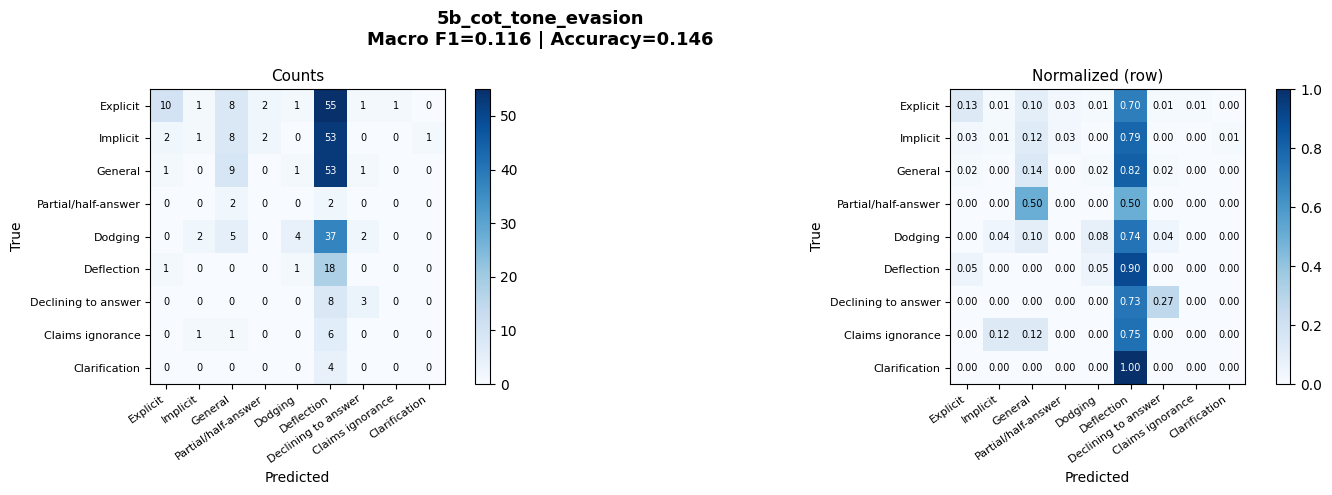

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5b_cot_tone_evasion_confusion_matrix.png


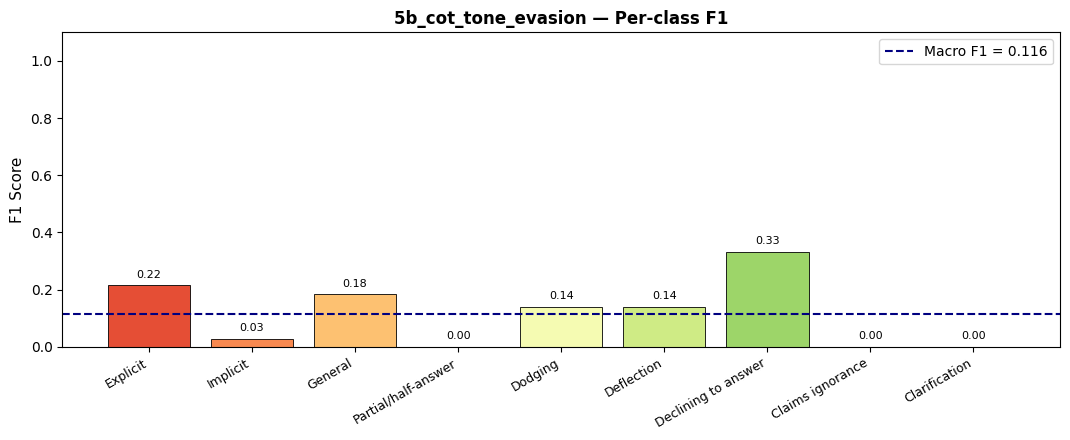

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5b_cot_tone_evasion_f1_per_class.png


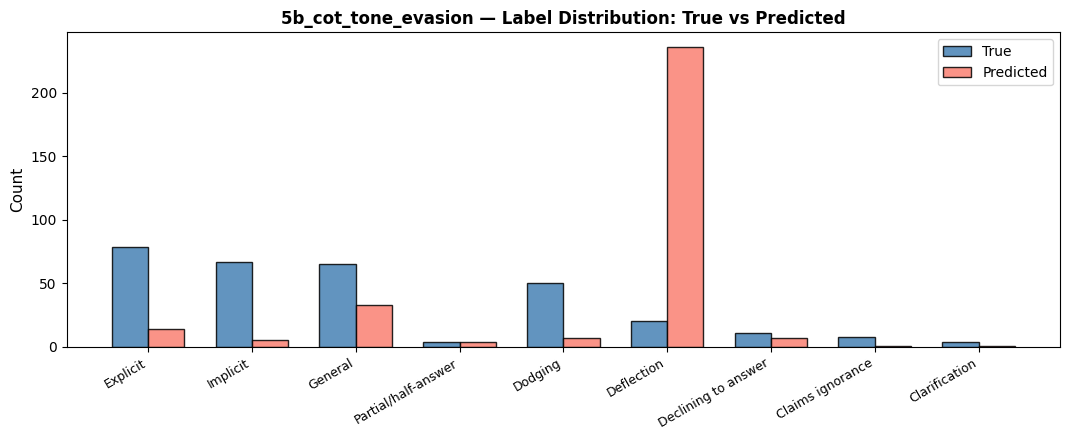

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5b_cot_tone_evasion_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5b_cot_tone_evasion_metrics.json


In [ ]:
print('POINT 5b — CoT + Table + Tone, 9-class evasion')
print(f'Samples: {len(df_test_1b_tone)}  |  max_new_tokens: {MAX_NEW_TOKENS_COT3}')

csv_path_5b = str(SAVE_DIR / '5b_cot_tone_evasion_predictions.csv')

df_res_5b = run_inference_cot_with_checkpoint(
    df            = df_test_1b_tone,
    system_prompt = SYSTEM_5B,
    label_col     = 'evasion_majority',
    valid_labels  = EVASION_LABELS,
    exp_name      = '5b_cot_tone_evasion',
    csv_path      = csv_path_5b,
    max_new_tokens= MAX_NEW_TOKENS_COT3,
)

print(f'Predictions loaded/saved from -> {csv_path_5b}')

if len(df_res_5b) == len(df_test_1b_tone):
    metrics_5b = evaluate_and_plot(
        df_results   = df_res_5b,
        valid_labels = EVASION_LABELS,
        exp_name     = '5b_cot_tone_evasion',
        save_dir     = SAVE_DIR,
    )
else:
    print(f'[!] Inference incomplete ({len(df_res_5b)}/{len(df_test_1b_tone)}). Re-run to continue.')


POINT 5c — CoT + Table + Tone, mapping 9-class to 3-class

  5c_cot_tone_evasion_to_clarity
  Total samples  : 308
  Parse errors   : 0  (0.0%)
  Valid samples  : 308
  Accuracy       : 0.6851
  Macro F1       : 0.4030
  Weighted F1    : 0.6086

                 precision    recall  f1-score   support

    Clear Reply       0.71      0.13      0.22        79
     Ambivalent       0.69      0.96      0.81       206
Clear Non-Reply       0.33      0.13      0.19        23

       accuracy                           0.69       308
      macro avg       0.58      0.41      0.40       308
   weighted avg       0.67      0.69      0.61       308



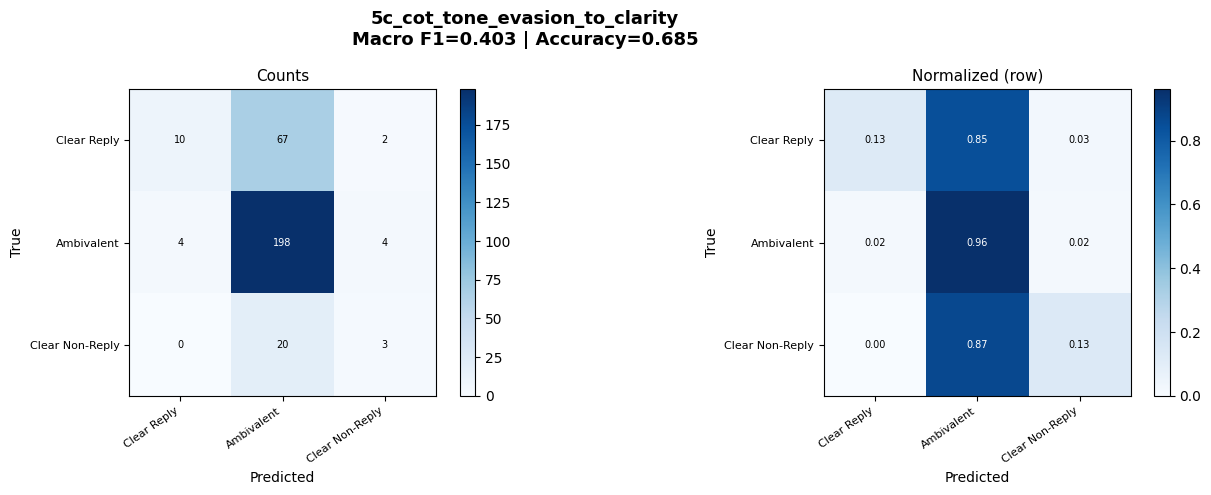

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5c_cot_tone_evasion_to_clarity_confusion_matrix.png


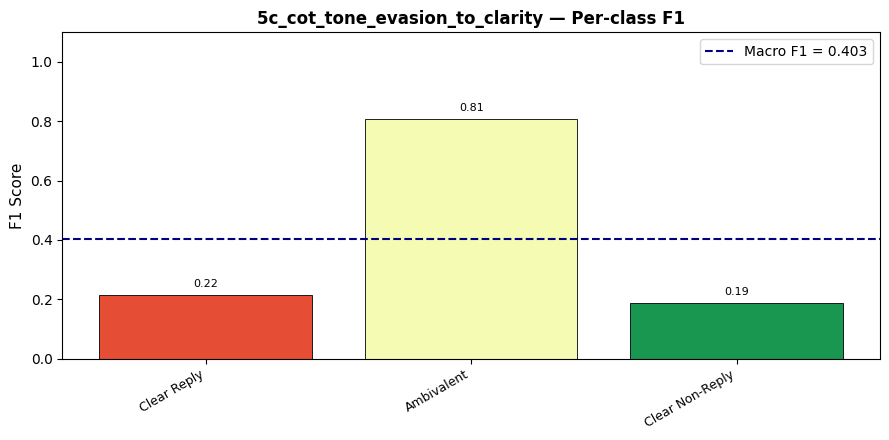

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5c_cot_tone_evasion_to_clarity_f1_per_class.png


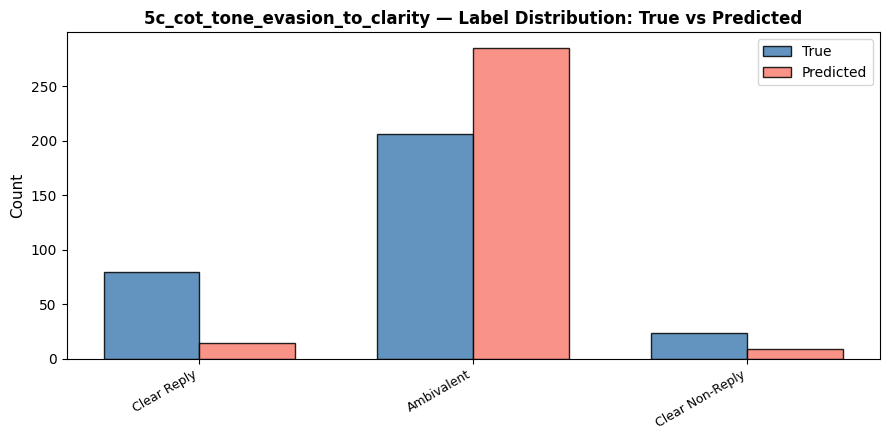

  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5c_cot_tone_evasion_to_clarity_label_distribution.png
  Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/5c_cot_tone_evasion_to_clarity_metrics.json


In [ ]:
print('POINT 5c — CoT + Table + Tone, mapping 9-class to 3-class')
if len(df_res_5b) == len(df_test_1b_tone):
    metrics_5c = apply_mapping_and_evaluate(
        evasion_csv_name = '5b_cot_tone_evasion_predictions.csv',
        exp_name         = '5c_cot_tone_evasion_to_clarity'
    )
else:
    print('[!] Cannot run task 1.1: evasion task incomplete.')


## 10 · Final Comparison — Points 1 to 5

Loads metrics from memory (if all cells were run top-to-bottom) or from disk
(if the notebook was interrupted and resumed). Produces a summary table and a
grouped bar chart comparing all four strategies on both tasks.

All metrics loaded.

  FINAL COMPARISON — Points 1 to 5 (Including Mapping)
ID             Method                       Task  Accuracy  Macro F1  Weighted F1  Parse Err
1a          Zero-Shot            3-class clarity    0.2500    0.2580       0.2993          0
2a                CoT            3-class clarity    0.2273    0.1897       0.2432          0
3a        CoT + Table            3-class clarity    0.5877    0.3669       0.5422          0
4a  CoT + Table + RAG            3-class clarity    0.5779    0.3565       0.5293          0
5a CoT + Table + Tone            3-class clarity    0.6667    0.3841       0.6093          2
1b          Zero-Shot            9-class evasion    0.1266    0.1178       0.0971          0
2b                CoT            9-class evasion    0.1498    0.1694       0.1234          1
3b        CoT + Table            9-class evasion    0.1661    0.1546       0.1605          1
4b  CoT + Table + RAG            9-class evasion    0.1889    0.1414       0.1623      

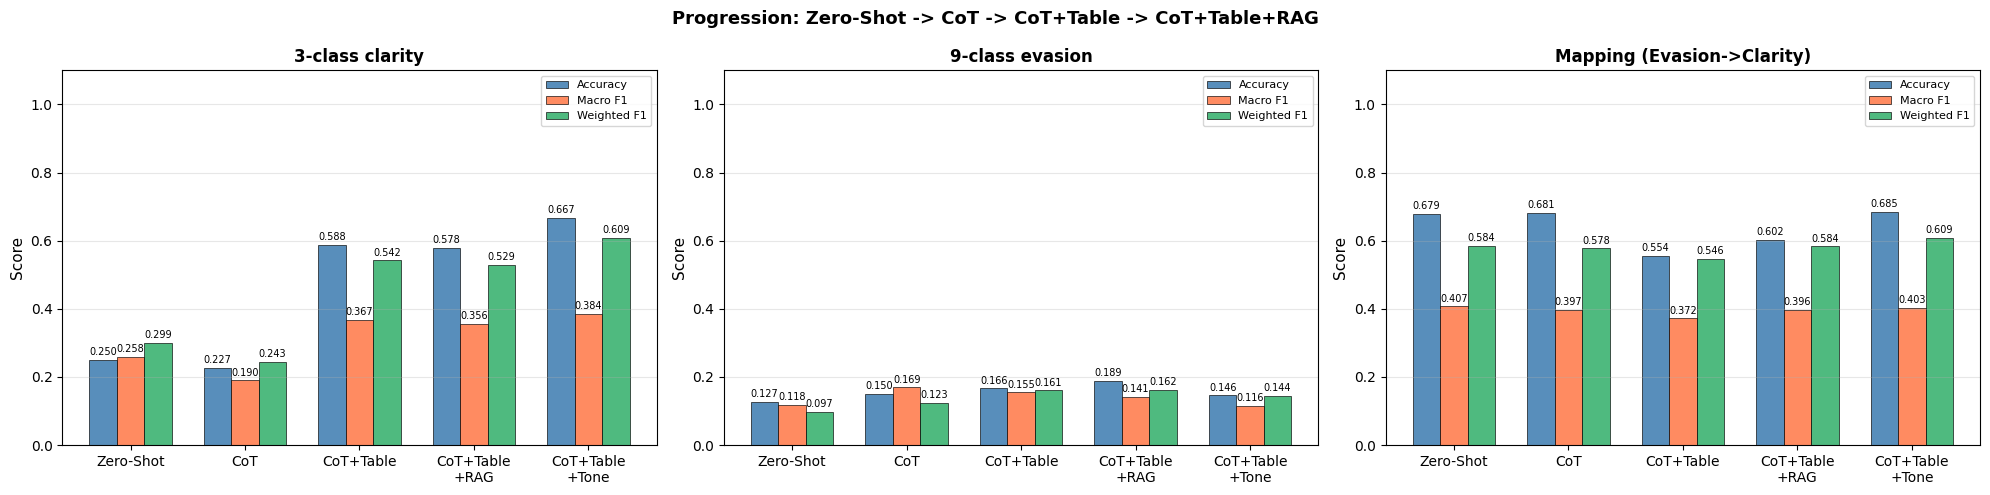

Saved -> /content/drive/MyDrive/progettoLLM/CLARITY/results/cot/final_comparison_1to5_with_mapping.png

Best method per task (by Macro F1):
  3-class clarity: CoT+Table+Tone  (Macro F1 = 0.3841)
  9-class evasion: CoT  (Macro F1 = 0.1694)
  Mapping (Evasion->Clarity): Zero-Shot  (Macro F1 = 0.4073)

All results saved to: /content/drive/MyDrive/progettoLLM/CLARITY/results/cot


In [ ]:
# ── FINAL COMPARISON AGGIORNATA CON MAPPING ───────────────────────────────────
import json as _json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_metrics(name: str) -> dict:
    fname_map = {
        '1a': '1a_zeroshot_clarity_metrics.json',
        '1b': '1b_zeroshot_evasion_metrics.json',
        '1c': '1c_zeroshot_evasion_to_clarity_metrics.json',
        '2a': '2a_cot_clarity_metrics.json',
        '2b': '2b_cot_evasion_metrics.json',
        '2c': '2c_cot_evasion_to_clarity_metrics.json',
        '3a': '3a_cot_table_clarity_metrics.json',
        '3b': '3b_cot_table_evasion_metrics.json',
        '3c': '3c_cot_table_evasion_to_clarity_metrics.json',
        '4a': '4a_cot_rag_clarity_metrics.json',
        '4b': '4b_cot_rag_evasion_metrics.json',
        '4c': '4c_cot_rag_evasion_to_clarity_metrics.json',
        '5a': '5a_cot_tone_clarity_metrics.json',
        '5b': '5b_cot_tone_evasion_metrics.json',
        '5c': '5c_cot_tone_evasion_to_clarity_metrics.json',
    }
    var_map = {
        '1a': 'metrics_1a', '1b': 'metrics_1b', '1c': 'metrics_1c',
        '2a': 'metrics_2a', '2b': 'metrics_2b', '2c': 'metrics_2c',
        '3a': 'metrics_3a', '3b': 'metrics_3b', '3c': 'metrics_3c',
        '4a': 'metrics_4a', '4b': 'metrics_4b', '4c': 'metrics_4c',
        '5a': 'metrics_5a', '5b': 'metrics_5b', '5c': 'metrics_5c',
    }
    try:
        return eval(var_map[name])
    except NameError:
        path = os.path.join(str(SAVE_DIR), fname_map[name])
        with open(path) as f:
            return _json.load(f)

all_m = {k: load_metrics(k) for k in ['1a', '1b', '1c', '2a', '2b', '2c', '3a', '3b', '3c', '4a', '4b', '4c', '5a', '5b', '5c']}
print('All metrics loaded.')

# ── Summary table ──────────────────────────────────────────────────────────
rows_data = [
    ('1a', 'Zero-Shot',         '3-class clarity'),
    ('2a', 'CoT',               '3-class clarity'),
    ('3a', 'CoT + Table',       '3-class clarity'),
    ('4a', 'CoT + Table + RAG', '3-class clarity'),
    ('5a', 'CoT + Table + Tone','3-class clarity'),
    ('1b', 'Zero-Shot',         '9-class evasion'),
    ('2b', 'CoT',               '9-class evasion'),
    ('3b', 'CoT + Table',       '9-class evasion'),
    ('4b', 'CoT + Table + RAG', '9-class evasion'),
    ('5b', 'CoT + Table + Tone','9-class evasion'),
    ('1c', 'Zero-Shot',         'Mapping (Evasion->Clarity)'),
    ('2c', 'CoT',               'Mapping (Evasion->Clarity)'),
    ('3c', 'CoT + Table',       'Mapping (Evasion->Clarity)'),
    ('4c', 'CoT + Table + RAG', 'Mapping (Evasion->Clarity)'),
    ('5c', 'CoT + Table + Tone','Mapping (Evasion->Clarity)'),
]

df_final = pd.DataFrame([{
    'ID': k, 'Method': method, 'Task': task,
    'Accuracy':    all_m[k]['accuracy'],
    'Macro F1':    all_m[k]['macro_f1'],
    'Weighted F1': all_m[k]['weighted_f1'],
    'Parse Err':   all_m[k]['n_parse_errors'],
} for k, method, task in rows_data])

print('\n' + '='*75)
print('  FINAL COMPARISON — Points 1 to 5 (Including Mapping)')
print('='*75)
print(df_final.to_string(index=False))

# ── Grouped bar chart (Esteso a 3 plot) ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Progression: Zero-Shot -> CoT -> CoT+Table -> CoT+Table+RAG',
             fontsize=13, fontweight='bold')

task_configs = [
    ('3-class clarity', ['1a', '2a', '3a', '4a', '5a'],
     ['Zero-Shot', 'CoT', 'CoT+Table', 'CoT+Table\n+RAG', 'CoT+Table\n+Tone']),
    ('9-class evasion', ['1b', '2b', '3b', '4b', '5b'],
     ['Zero-Shot', 'CoT', 'CoT+Table', 'CoT+Table\n+RAG', 'CoT+Table\n+Tone']),
    ('Mapping (Evasion->Clarity)', ['1c', '2c', '3c', '4c', '5c'],
     ['Zero-Shot', 'CoT', 'CoT+Table', 'CoT+Table\n+RAG', 'CoT+Table\n+Tone']),
]

for ax, (title, keys, xlabels) in zip(axes, task_configs):
    x = np.arange(len(keys))
    w = 0.24
    for offset, mkey, color, label in zip(
        [-w, 0, w],
        ['accuracy', 'macro_f1', 'weighted_f1'],
        ['steelblue', 'coral', 'mediumseagreen'],
        ['Accuracy', 'Macro F1', 'Weighted F1'],
    ):
        vals = [all_m[k][mkey] for k in keys]
        bars = ax.bar(x + offset, vals, w, label=label,
                      color=color, edgecolor='black', linewidth=0.5, alpha=0.9)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.008,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
p = str(SAVE_DIR / 'final_comparison_1to5_with_mapping.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {p}')

# ── Best method per task ───────────────────────────────────────────────────
print('\nBest method per task (by Macro F1):')
for task_label, keys, method_names in [
    ('3-class clarity', ['1a','2a','3a','4a','5a'], ['Zero-Shot','CoT','CoT+Table','CoT+Table+RAG','CoT+Table+Tone']),
    ('9-class evasion', ['1b','2b','3b','4b','5b'], ['Zero-Shot','CoT','CoT+Table','CoT+Table+RAG','CoT+Table+Tone']),
    ('Mapping (Evasion->Clarity)', ['1c','2c','3c','4c','5c'], ['Zero-Shot','CoT','CoT+Table','CoT+Table+RAG','CoT+Table+Tone']),
]:
    f1s = [(all_m[k]['macro_f1'], name) for k, name in zip(keys, method_names)]
    best_f1, best_name = max(f1s, key=lambda x: x[0])
    print(f'  {task_label}: {best_name}  (Macro F1 = {best_f1:.4f})')

# ── Save final CSV ─────────────────────────────────────────────────────────
df_final.to_csv(str(SAVE_DIR / 'final_summary_1to5_with_mapping.csv'), index=False)
print(f'\nAll results saved to: {SAVE_DIR}')